# V0 spatial calibration v11 — staged transverse solution

This notebook deliberately solves the detector correction in **separate physical stages**.

**Stage 1 (active here):** one global radial stretch about a fixed pivot,
\[
r_{\rm corr}=r_0+(1+s)(r-r_0),\qquad \Delta r=-s(r-r_0).
\]
Only the curvature/momentum magnitude is allowed to respond; the input momentum direction is kept fixed. The fit is driven mainly by the held-out-\(p_T\)-binned \(K_S^0\) mass scale, with a small width term and a weak residual guard. Charge balance is QA only.

**Stage 2:** freeze Stage 1, then learn \(r\Delta\phi\) from real \(K_S^0\) width minimization + global charge balance.  
**Stage 3:** optional \(\Delta z\), off by default.

The notebook intentionally stops after Stage 1 so its physics can be checked before adding another degree of freedom.


In [1]:
# ============================================================
# Imports and configuration
# ============================================================

from pathlib import Path
from array import array
import copy, gc, json, math, os, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from scipy.optimize import minimize

try:
    import ROOT as root
except ImportError:
    root = None

seed = 12345
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_float32_matmul_precision('high')


Welcome to JupyROOT 6.30/06


/home/yoren/.local/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [2]:
requested_cpu_threads = 6
available_cpu_threads = int(os.environ.get('SLURM_CPUS_PER_TASK', os.cpu_count() or requested_cpu_threads))
cpu_threads = max(1, min(requested_cpu_threads, available_cpu_threads))

torch.set_num_threads(cpu_threads)

try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print('PyTorch CPU threads:', torch.get_num_threads())

PyTorch CPU threads: 6


In [3]:

# Input written by ExportV0SpatialResidualTrainingCSV.C.
csv_dir = Path('/media/yoren/T7_Shield/sPHENIX/tracking/csvs')
csv_prefix = 'v0_spatial_training'
candidate_csv = csv_dir / f'{csv_prefix}_candidates.csv'
cluster_csv = csv_dir / f'{csv_prefix}_clusters.csv'

# First run: radial calibration only.
run_stage1_scan = True
run_stage1_fit = True
run_lambda_validation = False
run_stage2 = False
run_stage3 = False

training_profile = 'short'  # 'short' or 'long'

# Beam position used by the V0 reconstruction/exporter.
beam_x_cm, beam_y_cm, beam_z_cm = 0.158, 0.285, 0.0

# cut07 topology.
cut07_daughter_pt_min_gev = 0.20
cut07_lproj_min_cm = 2.0
cut07_abs_zvtx_max_cm = 10.0
cut07_abs_delta_pca_z_max_cm = 0.20
cut07_pair_dca_max_cm = 0.50
cut07_dira_min = 0.95
maximum_absolute_daughter_eta = 1.0

# PID from stored TPC dE/dx.
dedx_scale = 0.015
pid_target_nsigma = 3.0
pid_other_veto_nsigma = 1.0
apply_pid_selection = False

# Narrow these before loading clusters if memory is tight.
k0s_cluster_mass_min, k0s_cluster_mass_max = 0.44, 0.56
lambda_cluster_mass_min, lambda_cluster_mass_max = 1.095, 1.140
k0s_cluster_pair_pt_min, k0s_cluster_pair_pt_max = None, 3.0
lambda_cluster_pair_pt_min, lambda_cluster_pair_pt_max = None, None
load_lambda_validation_clusters = True

profiles = {
    'short': {
        'description': 'quick radial-calibration test',
        'k0s_low_pt_keep_fraction': 0.30,
        'lambda_low_pt_keep_fraction': 0.40,
        'prune_transition_start_pt_gev': 0.40,
        'prune_full_keep_pt_gev': 2.00,
        'maximum_k0s_candidates': 70_000,
        'maximum_lambda_candidates_per_channel': 4_000,
        'maximum_validation_candidates': 8_000,
        'stage1_scan_candidates': 5_000,
        'stage1_epochs': 20,
    },
    'long': {
        'description': 'full radial-calibration run',
        'k0s_low_pt_keep_fraction': 0.35,
        'lambda_low_pt_keep_fraction': 0.55,
        'prune_transition_start_pt_gev': 0.40,
        'prune_full_keep_pt_gev': 1.60,
        'maximum_k0s_candidates': 180_000,
        'maximum_lambda_candidates_per_channel': 15_000,
        'maximum_validation_candidates': 30_000,
        'stage1_scan_candidates': 12_000,
        'stage1_epochs': 30,
    },
}
if training_profile not in profiles:
    raise KeyError(f'Unknown training_profile={training_profile!r}; choose {list(profiles)}')
profile = profiles[training_profile]

k0s_low_pt_keep_fraction = profile['k0s_low_pt_keep_fraction']
lambda_low_pt_keep_fraction = profile['lambda_low_pt_keep_fraction']
prune_transition_start_pt_gev = profile['prune_transition_start_pt_gev']
prune_full_keep_pt_gev = profile['prune_full_keep_pt_gev']
maximum_k0s_candidates = profile['maximum_k0s_candidates']
maximum_lambda_candidates_per_channel = profile['maximum_lambda_candidates_per_channel']
maximum_validation_candidates = profile['maximum_validation_candidates']
stage1_scan_candidates = profile['stage1_scan_candidates']
stage1_epochs = profile['stage1_epochs']

work_dir = Path(f'output/v0_spatial_calibration_v11_radial_{training_profile}')
cache_dir = work_dir / 'tensor_cache'
checkpoint_dir = work_dir / 'checkpoints'
work_dir.mkdir(parents=True, exist_ok=True)
cache_dir.mkdir(parents=True, exist_ok=True)
checkpoint_dir.mkdir(parents=True, exist_ok=True)

training_parity = 0
validation_parity = 1 - training_parity

pdg_kshort_mass = 0.497611
pion_mass = 0.13957039
kaon_mass = 0.493677
proton_mass = 0.9382720813
deuteron_mass = 1.87561294257
min_k0s_mass, max_k0s_mass = k0s_cluster_mass_min, k0s_cluster_mass_max

# TPC / cluster selection.
z_pad_cm = 102.325
central_membrane_tolerance_cm = 0.50
pad_plane_tolerance_cm = 0.75
maximum_clusters = 48
minimum_clusters_per_track = 30
minimum_tpc_modules_per_track = 3
minimum_track_radial_span_cm = 15.0
excluded_layers = {7, 21, 22, 23, 24, 37, 38, 39, 40, 54}
tpc_module_layer_ranges = ((7, 22), (23, 38), (39, 54))
use_recommended_clusters_only = True
use_kalman_used_clusters_only = False
maximum_abs_residual_normal_cm = 2.0
maximum_abs_residual_z_cm = 3.0
fallback_sigma_r_cm = 0.20
fallback_sigma_rphi_cm = 0.05
fallback_sigma_z_cm = 0.20
minimum_sigma_normal_cm = 0.05
cluster_csv_chunksize = 250_000
cluster_progress_print_every_n_chunks = 10
candidate_subsample_seed = seed + 101

# Full-field fast response. Stage 1 intentionally changes curvature only.
field_evaluation_mode = 'linearized'
field_gradient_step_cm = 1.0
lorentz_curvature_constant = 0.00299792458
minimum_refit_scale, maximum_refit_scale = 0.80, 1.20
momentum_scale_response_strength = 1.0
direction_correction_strength = 0.0
include_z_correction = False

# K0S mass bins and frozen mass-core model.
pt_mass_scale_bin_edges = np.array([0.5, 0.8, 1.1, 1.4, 1.8, 2.2, 3.0], dtype=np.float32)
pt_mass_scale_minimum_effective_entries = 20.0
k0s_mass_fit_signal_fraction_min, k0s_mass_fit_signal_fraction_max = 0.02, 0.75
k0s_mass_fit_mean_min, k0s_mass_fit_mean_max = 0.486, 0.506
k0s_mass_fit_sigma_min_gev, k0s_mass_fit_sigma_max_gev = 0.003, 0.010
k0s_mass_core_nsigma = 2.0
minimum_signal_probability_for_physics = 0.0
k0s_mass_model_minimum_candidates_per_pt_bin = 300
maximum_allowed_sideband_signal_probability = 0.20
minimum_peak_minus_sideband_probability = 0.25

# Stage 1: one global radial stretch about a fixed pivot.
# r_corrected = r0 + (1+s)(r-r0), so map Delta r = -s(r-r0).
stage1_pivot_r_cm = 54.5
stage1_max_abs_stretch_fraction = 0.04
stage1_scan_min_fraction = -0.03
stage1_scan_max_fraction = 0.03
stage1_scan_points = 25
stage1_learning_rate = 5.0e-4
stage1_candidate_batch_size = 8192
stage1_validation_batch_size = 4096
stage1_mass_scale_gev = 0.001
stage1_pt_mass_weight = 1.0
stage1_inclusive_mass_weight = 0.15
stage1_width_weight = 0.05
stage1_residual_weight = 0.03
stage1_stretch_prior_weight = 0.005
stage1_pt_priority_power = 0.50
stage1_pt_priority_reference_gev = 1.0
stage1_pt_priority_maximum = 2.0
stage1_patience = 8
stage1_minimum_improvement = 1.0e-4

# Charge balance is QA only in Stage 1. Stage 2 will use it in the loss.
charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev = 0.20, 3.0
charge_balance_number_of_bins = 14
charge_balance_systematic_floor_fraction = 0.10
charge_balance_minimum_bin_effective_entries = 20.0

print('Profile:', training_profile, '-', profile['description'])
print('Work directory:', work_dir)
print('Stage 1 pivot:', stage1_pivot_r_cm, 'cm')
print('Stage 1 stretch bound:', 100 * stage1_max_abs_stretch_fraction, '%')
print('Stage 2/3 enabled:', run_stage2, run_stage3)


Profile: short - quick radial-calibration test
Work directory: output/v0_spatial_calibration_v11_radial_short
Stage 1 pivot: 54.5 cm
Stage 1 stretch bound: 4.0 %
Stage 2/3 enabled: False False


## 1. Load a compact K0S/Lambda sample

Candidate cuts and smooth \(p_T\) pruning happen **before** the cluster CSV is streamed. The large cluster table is read in chunks and only useful rows are retained.


In [4]:
# ============================================================
# Candidate selection, smooth pruning, and memory-safe cluster loading
# ============================================================


def candidate_key(candidate_id, channel):
    return np.asarray(candidate_id, dtype=np.int64) * 4 + np.asarray(channel, dtype=np.int64)


def radial_module_from_layer(layer):
    layer = np.asarray(layer)
    out = np.full(layer.shape, -1, dtype=np.int8)
    for module_index, (first_layer, last_layer) in enumerate(tpc_module_layer_ranges):
        out[(layer >= first_layer) & (layer <= last_layer)] = module_index
    return out


def sector_from_phi(phi):
    wrapped = np.mod(np.asarray(phi, dtype=np.float32) + np.float32(math.pi), np.float32(2.0 * math.pi))
    return np.clip(np.floor(wrapped / np.float32(2.0 * math.pi / 12.0)).astype(np.int8), 0, 11)


def smoothstep01(x):
    x = np.clip(np.asarray(x, dtype=np.float64), 0.0, 1.0)
    return x * x * (3.0 - 2.0 * x)


def smooth_keep_probability(pair_pt, low_fraction, gamma=1.0):
    pt = np.asarray(pair_pt, dtype=np.float64)
    x = (pt - prune_transition_start_pt_gev) / max(prune_full_keep_pt_gev - prune_transition_start_pt_gev, 1.0e-6)
    shape = smoothstep01(x) ** gamma
    return low_fraction + (1.0 - low_fraction) * shape


def adaptive_keep_probability(pair_pt, target_candidates, low_fraction):
    pt = np.asarray(pair_pt, dtype=np.float64)

    if target_candidates is None or target_candidates >= len(pt):
        return np.ones(len(pt), dtype=np.float64), 1.0

    target_candidates = float(target_candidates)
    high_count = np.count_nonzero(pt >= prune_full_keep_pt_gev)

    if target_candidates <= high_count:
        raise RuntimeError(
            f'Target {target_candidates:.0f} is smaller than the {high_count} candidates '
            f'already above {prune_full_keep_pt_gev:.2f} GeV/c.'
        )

    minimum_expected = high_count + low_fraction * (len(pt) - high_count)

    if target_candidates < minimum_expected:
        allowed_floor = (target_candidates - high_count) / max(len(pt) - high_count, 1)
        low_fraction = max(0.0, 0.8 * allowed_floor)
        print(f'Adjusted low-pT keep floor to {low_fraction:.4f} to reach target.')

    gamma_low = 0.05
    gamma_high = 100.0

    for _ in range(60):
        gamma = 0.5 * (gamma_low + gamma_high)
        probability = smooth_keep_probability(pt, low_fraction, gamma)
        expected = probability.sum()

        if expected > target_candidates:
            gamma_low = gamma
        else:
            gamma_high = gamma

    gamma = gamma_high
    probability = smooth_keep_probability(pt, low_fraction, gamma)

    return probability, gamma


def smooth_prune(frame, low_fraction, maximum, seed_value, label):
    if frame.empty:
        return frame

    before_pt = frame['pair_pt'].to_numpy(np.float64)
    probability, gamma = adaptive_keep_probability(before_pt, maximum, low_fraction)

    rng = np.random.default_rng(seed_value)
    keep = rng.random(len(frame)) < probability
    retained = frame.loc[keep].copy()
    after_pt = retained['pair_pt'].to_numpy(np.float64)

    print(
        f'{label}: {len(before_pt):,} -> {len(retained):,}; '
        f'target={maximum:,}; expected={probability.sum():,.0f}; gamma={gamma:.3f}'
    )

    bins = np.linspace(0.0, 3.0, 61)
    before_counts, _ = np.histogram(before_pt, bins=bins)
    after_counts, _ = np.histogram(after_pt, bins=bins)
    centers = 0.5 * (bins[:-1] + bins[1:])

    observed_keep = np.divide(
        after_counts,
        before_counts,
        out=np.full(len(after_counts), np.nan, dtype=float),
        where=before_counts > 0,
    )

    normalization = max(before_counts.max(), 1)

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    ax.step(centers, before_counts / normalization, where='mid', label=f'{label}: before')
    ax.step(centers, after_counts / normalization, where='mid', label=f'{label}: retained')

    ax2 = ax.twinx()
    grid = np.linspace(0.0, 3.0, 400)
    grid_probability = smooth_keep_probability(grid, low_fraction, gamma)
    ax2.plot(grid, grid_probability, linestyle='--', label='target keep probability')
    ax2.scatter(centers, observed_keep, s=12, alpha=0.5, label='observed retained fraction')

    ax.set_xlabel(r'candidate $p_T$ [GeV/$c$]')
    ax.set_ylabel('candidates / maximum original bin')
    ax2.set_ylabel('retained fraction')
    ax2.set_ylim(0.0, 1.05)

    ax.legend(loc='upper right')
    ax2.legend(loc='center right')
    ax.set_title(f'{label}: smooth stochastic pruning ({len(before_pt):,} → {len(retained):,})')

    plt.show()

    return retained


# ------------------------- ALEPH dE/dx PID -------------------------

def aleph_expected_dedx(momentum, mass):
    p = np.maximum(np.asarray(momentum, dtype=np.float64), 1.0e-6)
    bg = p / mass
    beta = bg / np.sqrt(1.0 + bg * bg)
    p1, p2, p3, p4, p5 = 0.1819, 10.8175, 1.1674e-5, 3.0199, 5.0
    return p1 / np.maximum(beta, 1.0e-8) ** p4 * (p2 - beta ** p4 - np.log(p3 + bg ** (-p5)))


def universal_log_dedx_sigma(expected):
    expected = np.maximum(np.asarray(expected, dtype=np.float64), 1.0e-8)
    return np.sqrt(0.07690 ** 2 + 0.16914 ** 2 / expected ** 0.40000)


def species_width_ratio(momentum, species):
    p = np.asarray(momentum, dtype=np.float64)
    if species == 'pi':
        return np.ones_like(p)
    if species == 'k':
        pc = np.clip(p, 0.23, 0.53)
        return 0.910 + 0.628 * (np.log(pc) - np.log(0.23))
    if species == 'p':
        pc = np.clip(p, 0.20, 0.93)
        return 1.077 - 0.037 * (np.log(pc) - np.log(0.20))
    if species == 'd':
        pc = np.clip(p, 0.29, 1.73)
        return 0.834 + 0.164 * (np.log(pc) - np.log(0.29))
    raise KeyError(species)


species_masses = {'pi': pion_mass, 'k': kaon_mass, 'p': proton_mass, 'd': deuteron_mass}


def dedx_nsigma(measured_dedx, momentum, species):
    measured = np.asarray(measured_dedx, dtype=np.float64) * dedx_scale
    expected = aleph_expected_dedx(momentum, species_masses[species])
    sigma = universal_log_dedx_sigma(expected) * species_width_ratio(momentum, species)
    valid = np.isfinite(measured) & (measured > 0) & np.isfinite(expected) & (expected > 0) & np.isfinite(sigma) & (sigma > 0)
    out = np.full(measured.shape, np.nan, dtype=np.float32)
    out[valid] = ((np.log(measured[valid]) - np.log(expected[valid])) / sigma[valid]).astype(np.float32)
    return out


def pid_accept(nsigma, target):
    if not apply_pid_selection:
        return np.ones_like(nsigma[target], dtype=np.bool_)
    target_ok = np.abs(nsigma[target]) < pid_target_nsigma
    competitors = [species for species in ['pi', 'k', 'p', 'd'] if species != target]
    other_distance = np.minimum.reduce([np.abs(nsigma[species]) for species in competitors])
    return target_ok & np.isfinite(other_distance) & (other_distance > pid_other_veto_nsigma)



Raw candidates: 823,490
After cut07: 134,652
After cut07 + PID: 134,652
K0S before smooth pruning: 119,112
K0S: 119,112 -> 70,020; target=70,000; expected=70,000; gamma=1.650


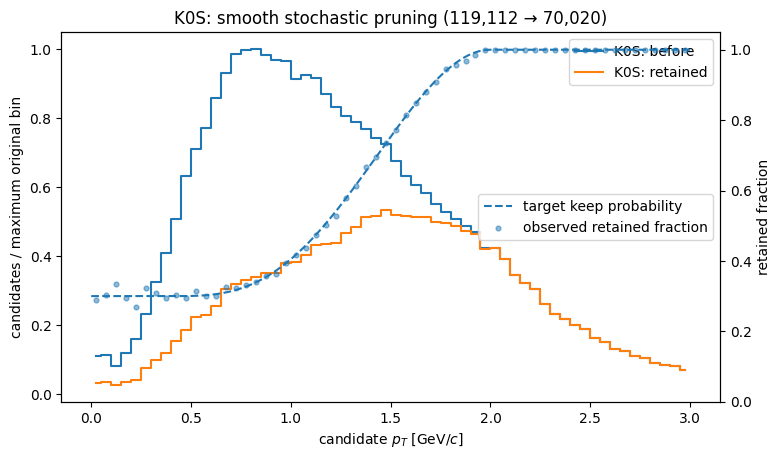

K0S retained for cluster loading: 70,020
Lambda before smooth pruning: 4,230
Lambda: 4,230 -> 3,984; target=4,000; expected=4,000; gamma=0.711


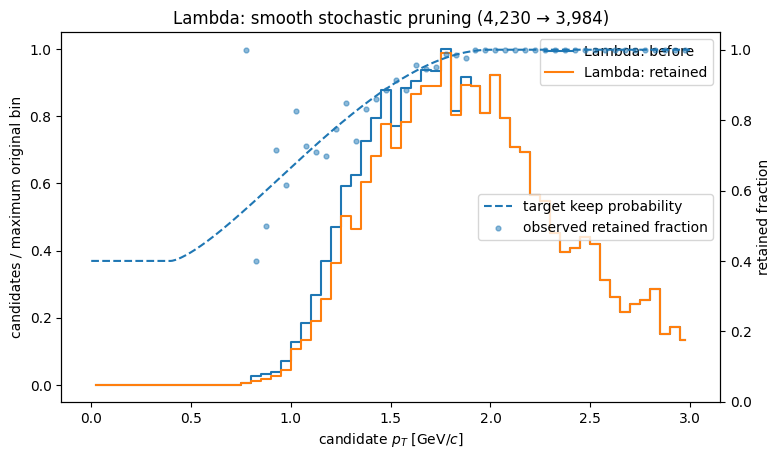

Lambda retained for cluster loading: 3,984
AntiLambda before smooth pruning: 4,154
AntiLambda: 4,154 -> 4,014; target=4,000; expected=4,000; gamma=0.544


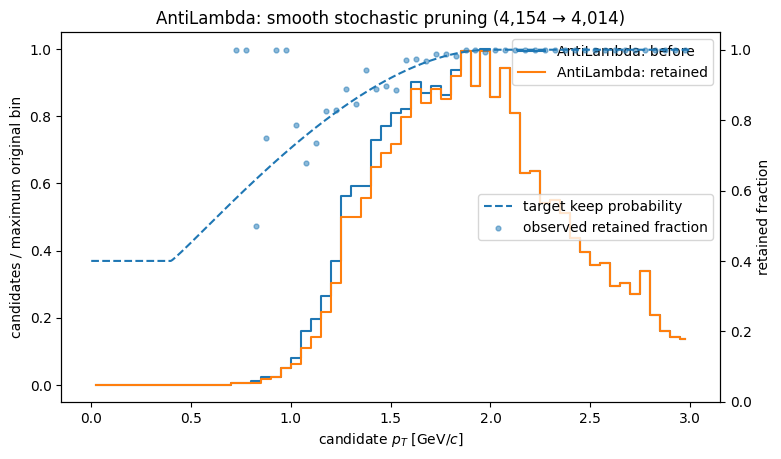

AntiLambda retained for cluster loading: 4,014
Total retained candidates: 78,018
channel  side1  event_parity
0        0      0               19195
                1               19570
         1      0               15530
                1               15725
1        0      0                1053
                1                1042
         1      0                 929
                1                 960
2        0      0                1094
                1                1125
         1      0                 914
                1                 881
dtype: int64
chunk 1: read=250,000, candidate matched=25,881, retained=20,819
chunk 10: read=2,500,000, candidate matched=242,214, retained=195,076
chunk 20: read=5,000,000, candidate matched=484,150, retained=389,596
chunk 30: read=7,500,000, candidate matched=717,040, retained=576,847
chunk 40: read=10,000,000, candidate matched=964,107, retained=775,558
chunk 50: read=12,500,000, candidate matched=1,208,633, retained=972,153
ch

In [5]:

# ------------------------- candidate table -------------------------

candidate_columns = [
    'candidate_id', 'event_parity', 'channel', 'same_side', 'side1', 'side2', 'charge1', 'charge2',
    'px1', 'py1', 'pz1', 'pt1', 'phi1', 'eta1', 'px2', 'py2', 'pz2', 'pt2', 'phi2', 'eta2',
    'pca_x', 'pca_y', 'pca_z', 'pca1_z', 'pca2_z', 'pair_dca', 'dira', 'dedx1', 'dedx2',
    'selected_mass', 'pair_pt', 'pass_cut03', 'pass_pion_pid', 'pass_signed_delta_phi',
]
float32_columns = [
    'charge1', 'charge2', 'px1', 'py1', 'pz1', 'pt1', 'phi1', 'eta1', 'px2', 'py2', 'pz2', 'pt2', 'phi2', 'eta2',
    'pca_x', 'pca_y', 'pca_z', 'pca1_z', 'pca2_z', 'pair_dca', 'dira', 'dedx1', 'dedx2', 'selected_mass', 'pair_pt',
]
candidate_dtype = {name: np.float32 for name in float32_columns}
candidate_dtype.update({'candidate_id': np.int64, 'event_parity': np.int8, 'channel': np.int8, 'same_side': np.int8, 'side1': np.int8, 'side2': np.int8, 'pass_cut03': np.int8, 'pass_pion_pid': np.int8, 'pass_signed_delta_phi': np.int8})

candidate_header = pd.read_csv(candidate_csv, nrows=0).columns
missing = sorted(set(candidate_columns) - set(candidate_header))
if missing:
    raise KeyError(f'Missing candidate columns required by v10: {missing}')
candidates = pd.read_csv(candidate_csv, usecols=candidate_columns, dtype=candidate_dtype)
print('Raw candidates:', f'{len(candidates):,}')

# Geometry and cut07 quantities.
pair_px = candidates['px1'].to_numpy() + candidates['px2'].to_numpy()
pair_py = candidates['py1'].to_numpy() + candidates['py2'].to_numpy()
pair_pz = candidates['pz1'].to_numpy() + candidates['pz2'].to_numpy()
pair_p = np.sqrt(pair_px ** 2 + pair_py ** 2 + pair_pz ** 2)
flight_x = candidates['pca_x'].to_numpy() - beam_x_cm
flight_y = candidates['pca_y'].to_numpy() - beam_y_cm
flight_z = candidates['pca_z'].to_numpy() - beam_z_cm
candidates['lproj'] = ((pair_px * flight_x + pair_py * flight_y + pair_pz * flight_z) / np.maximum(pair_p, 1.0e-8)).astype(np.float32)
candidates['abs_delta_pca_z'] = np.abs(candidates['pca1_z'].to_numpy() - candidates['pca2_z'].to_numpy()).astype(np.float32)

eta_ok = np.isfinite(candidates['eta1']) & np.isfinite(candidates['eta2']) & (np.abs(candidates['eta1']) < maximum_absolute_daughter_eta) & (np.abs(candidates['eta2']) < maximum_absolute_daughter_eta)
cut07 = eta_ok & (candidates['pt1'] > cut07_daughter_pt_min_gev) & (candidates['pt2'] > cut07_daughter_pt_min_gev)
cut07 &= candidates['lproj'] > cut07_lproj_min_cm
cut07 &= np.abs(candidates['pca_z']) < cut07_abs_zvtx_max_cm
cut07 &= candidates['abs_delta_pca_z'] < cut07_abs_delta_pca_z_max_cm
cut07 &= np.abs(candidates['pair_dca']) < cut07_pair_dca_max_cm
cut07 &= candidates['dira'] > cut07_dira_min
cut07 &= candidates['pass_signed_delta_phi'].astype(bool)
candidates['pass_cut07'] = cut07.astype(np.int8)

# Recompute normal PID for all candidates from dE/dx.
for daughter in [1, 2]:
    p = np.sqrt(candidates[f'px{daughter}'] ** 2 + candidates[f'py{daughter}'] ** 2 + candidates[f'pz{daughter}'] ** 2).to_numpy(np.float64)
    nsigma = {species: dedx_nsigma(candidates[f'dedx{daughter}'].to_numpy(), p, species) for species in ['pi', 'k', 'p', 'd']}
    for species in ['pi', 'k', 'p', 'd']:
        candidates[f'nsigma_{species}{daughter}'] = nsigma[species]
    candidates[f'pid_pi{daughter}'] = pid_accept(nsigma, 'pi').astype(np.int8)
    candidates[f'pid_p{daughter}'] = pid_accept(nsigma, 'p').astype(np.int8)

channel = candidates['channel'].to_numpy()
charge1 = candidates['charge1'].to_numpy()
charge2 = candidates['charge2'].to_numpy()
pid_pi1 = candidates['pid_pi1'].astype(bool).to_numpy()
pid_pi2 = candidates['pid_pi2'].astype(bool).to_numpy()
pid_p1 = candidates['pid_p1'].astype(bool).to_numpy()
pid_p2 = candidates['pid_p2'].astype(bool).to_numpy()
pid_mask = np.zeros(len(candidates), dtype=bool)
pid_mask[channel == 0] = (pid_pi1 & pid_pi2)[channel == 0]
lam = channel == 1
pid_mask[lam] = (np.where(charge1 > 0, pid_p1, pid_pi1) & np.where(charge2 > 0, pid_p2, pid_pi2))[lam]
anti = channel == 2
pid_mask[anti] = (np.where(charge1 < 0, pid_p1, pid_pi1) & np.where(charge2 < 0, pid_p2, pid_pi2))[anti]
candidates['pass_pid'] = pid_mask.astype(np.int8)

print('After cut07:', f'{candidates["pass_cut07"].sum():,}')
print('After cut07 + PID:', f'{np.count_nonzero(candidates["pass_cut07"].astype(bool) & candidates["pass_pid"].astype(bool)):,}')

# Channel selections and smooth pT pruning happen BEFORE cluster loading.
selected_frames = []
for channel_value, label, mass_min, mass_max, pt_min, pt_max, low_fraction, maximum in [
    (0, 'K0S', k0s_cluster_mass_min, k0s_cluster_mass_max, k0s_cluster_pair_pt_min, k0s_cluster_pair_pt_max, k0s_low_pt_keep_fraction, maximum_k0s_candidates),
    (1, 'Lambda', lambda_cluster_mass_min, lambda_cluster_mass_max, lambda_cluster_pair_pt_min, lambda_cluster_pair_pt_max, lambda_low_pt_keep_fraction, maximum_lambda_candidates_per_channel),
    (2, 'AntiLambda', lambda_cluster_mass_min, lambda_cluster_mass_max, lambda_cluster_pair_pt_min, lambda_cluster_pair_pt_max, lambda_low_pt_keep_fraction, maximum_lambda_candidates_per_channel),
]:
    if channel_value in [1, 2] and not load_lambda_validation_clusters:
        continue
    frame = candidates.loc[(candidates['channel'] == channel_value) & candidates['pass_cut07'].astype(bool) & candidates['pass_pid'].astype(bool)].copy()
    frame = frame.loc[(frame['selected_mass'] >= mass_min) & (frame['selected_mass'] <= mass_max)]
    if pt_min is not None:
        frame = frame.loc[frame['pair_pt'] >= pt_min]
    if pt_max is not None:
        frame = frame.loc[frame['pair_pt'] <= pt_max]
    print(f'{label} before smooth pruning: {len(frame):,}')
    frame = smooth_prune(frame, low_fraction, maximum, candidate_subsample_seed + channel_value * 100, label)
    print(f'{label} retained for cluster loading: {len(frame):,}')
    selected_frames.append(frame)

candidates = pd.concat(selected_frames, ignore_index=True, copy=False)
candidates.drop_duplicates(['candidate_id', 'channel'], inplace=True)
candidates.reset_index(drop=True, inplace=True)
accepted_candidate_keys = np.unique(candidate_key(candidates['candidate_id'].to_numpy(), candidates['channel'].to_numpy()))
print('Total retained candidates:', f'{len(candidates):,}')
print(candidates.groupby(['channel', 'side1', 'event_parity'], observed=True).size())

# ------------------------- cluster table -------------------------

required_cluster_columns = [
    'candidate_id', 'channel', 'daughter', 'track_id', 'charge', 'side', 'layer',
    'cluster_x', 'cluster_y', 'cluster_z', 'cluster_r', 'cluster_phi',
    'fit_x', 'fit_y', 'fit_z', 'fit_px', 'fit_py', 'fit_pz',
    'residual_r', 'residual_rphi', 'residual_z',
    'assigned_sigma_r', 'assigned_sigma_rphi', 'assigned_sigma_z',
    'recommended_for_reference_fit', 'kalman_measurement_used',
]
cluster_header = pd.read_csv(cluster_csv, nrows=0).columns
missing = sorted(set(required_cluster_columns) - set(cluster_header))
if missing:
    raise KeyError(f'Missing cluster columns: {missing}')
cluster_columns = list(required_cluster_columns)
for optional in ['event_parity', 'kalman_measurement_chi2']:
    if optional in cluster_header:
        cluster_columns.append(optional)

cluster_dtype = {
    'candidate_id': np.int64, 'channel': np.int8, 'daughter': np.int8, 'track_id': np.int64, 'charge': np.float32, 'side': np.int8, 'layer': np.int16,
    'cluster_x': np.float32, 'cluster_y': np.float32, 'cluster_z': np.float32, 'cluster_r': np.float32, 'cluster_phi': np.float32,
    'fit_x': np.float32, 'fit_y': np.float32, 'fit_z': np.float32, 'fit_px': np.float32, 'fit_py': np.float32, 'fit_pz': np.float32,
    'residual_r': np.float32, 'residual_rphi': np.float32, 'residual_z': np.float32,
    'assigned_sigma_r': np.float32, 'assigned_sigma_rphi': np.float32, 'assigned_sigma_z': np.float32,
    'recommended_for_reference_fit': np.int8, 'kalman_measurement_used': np.int8,
}
if 'event_parity' in cluster_columns:
    cluster_dtype['event_parity'] = np.int8
if 'kalman_measurement_chi2' in cluster_columns:
    cluster_dtype['kalman_measurement_chi2'] = np.float32


def process_cluster_chunk(chunk):
    keys = candidate_key(chunk['candidate_id'].to_numpy(), chunk['channel'].to_numpy())
    candidate_keep = np.isin(keys, accepted_candidate_keys, assume_unique=False)
    matched_count = int(candidate_keep.sum())
    if matched_count == 0:
        return None, 0
    chunk = chunk.loc[candidate_keep].copy()

    side = chunk['side'].to_numpy()
    z = chunk['cluster_z'].to_numpy()
    layer = chunk['layer'].to_numpy()
    physical_side_z_valid = ((side == 0) & (z <= central_membrane_tolerance_cm) & (z >= -z_pad_cm - pad_plane_tolerance_cm)) | ((side == 1) & (z >= -central_membrane_tolerance_cm) & (z <= z_pad_cm + pad_plane_tolerance_cm))
    basic_keep = physical_side_z_valid & (layer >= 7) & (layer <= 54) & ~np.isin(layer, list(excluded_layers))
    if use_recommended_clusters_only:
        basic_keep &= chunk['recommended_for_reference_fit'].to_numpy().astype(bool)
    if use_kalman_used_clusters_only:
        basic_keep &= chunk['kalman_measurement_used'].to_numpy().astype(bool)
    if not np.any(basic_keep):
        return None, matched_count
    chunk = chunk.loc[basic_keep].copy()

    sigma_r = chunk['assigned_sigma_r'].to_numpy(copy=True)
    sigma_rphi = chunk['assigned_sigma_rphi'].to_numpy(copy=True)
    sigma_z = chunk['assigned_sigma_z'].to_numpy(copy=True)
    sigma_r[~np.isfinite(sigma_r) | (sigma_r <= 0)] = fallback_sigma_r_cm
    sigma_rphi[~np.isfinite(sigma_rphi) | (sigma_rphi <= 0)] = fallback_sigma_rphi_cm
    sigma_z[~np.isfinite(sigma_z) | (sigma_z <= 0)] = fallback_sigma_z_cm

    fit_px = chunk['fit_px'].to_numpy()
    fit_py = chunk['fit_py'].to_numpy()
    fit_pt = np.hypot(fit_px, fit_py).astype(np.float32)
    valid_tangent = np.isfinite(fit_pt) & (fit_pt > 1.0e-8)
    tangent_x = np.full(len(chunk), np.nan, dtype=np.float32)
    tangent_y = np.full(len(chunk), np.nan, dtype=np.float32)
    tangent_x[valid_tangent] = fit_px[valid_tangent] / fit_pt[valid_tangent]
    tangent_y[valid_tangent] = fit_py[valid_tangent] / fit_pt[valid_tangent]
    normal_x, normal_y = -tangent_y, tangent_x

    phi = chunk['cluster_phi'].to_numpy()
    radial_x, radial_y = np.cos(phi), np.sin(phi)
    normal_projection_r = (normal_x * radial_x + normal_y * radial_y).astype(np.float32)
    normal_projection_rphi = (normal_x * (-radial_y) + normal_y * radial_x).astype(np.float32)
    dx = chunk['cluster_x'].to_numpy() - chunk['fit_x'].to_numpy()
    dy = chunk['cluster_y'].to_numpy() - chunk['fit_y'].to_numpy()
    residual_normal_xy = (dx * normal_x + dy * normal_y).astype(np.float32)
    residual_r_orthogonal = (residual_normal_xy * normal_projection_r).astype(np.float32)
    residual_rphi_orthogonal = (residual_normal_xy * normal_projection_rphi).astype(np.float32)
    sigma_normal = np.sqrt((normal_projection_r * sigma_r) ** 2 + (normal_projection_rphi * sigma_rphi) ** 2).astype(np.float32)
    sigma_normal = np.maximum(sigma_normal, minimum_sigma_normal_cm)

    residual_z = chunk['residual_z'].to_numpy()
    keep = np.isfinite(residual_normal_xy) & np.isfinite(residual_z) & (np.abs(residual_normal_xy) < maximum_abs_residual_normal_cm) & (np.abs(residual_z) < maximum_abs_residual_z_cm)
    if not np.any(keep):
        return None, matched_count
    chunk = chunk.loc[keep].copy()
    sigma_r, sigma_rphi, sigma_z = sigma_r[keep], sigma_rphi[keep], sigma_z[keep]
    normal_projection_r, normal_projection_rphi = normal_projection_r[keep], normal_projection_rphi[keep]
    residual_normal_xy = residual_normal_xy[keep]
    residual_r_orthogonal, residual_rphi_orthogonal = residual_r_orthogonal[keep], residual_rphi_orthogonal[keep]
    sigma_normal, valid_tangent = sigma_normal[keep], valid_tangent[keep]

    chunk['sigma_r_filled'] = sigma_r.astype(np.float32)
    chunk['sigma_rphi_filled'] = sigma_rphi.astype(np.float32)
    chunk['sigma_z_filled'] = sigma_z.astype(np.float32)
    chunk['normal_projection_r'] = normal_projection_r
    chunk['normal_projection_rphi'] = normal_projection_rphi
    chunk['residual_normal_xy'] = residual_normal_xy
    chunk['residual_r_orthogonal'] = residual_r_orthogonal
    chunk['residual_rphi_orthogonal'] = residual_rphi_orthogonal
    chunk['sigma_normal'] = sigma_normal
    chunk['valid_fit_tangent'] = valid_tangent.astype(np.uint8)

    z = chunk['cluster_z'].to_numpy()
    chunk['drift_fraction'] = np.clip(1.0 - np.abs(z) / z_pad_cm, 0.0, 1.0).astype(np.float32)
    chunk['distance_from_pad_plane_cm'] = np.maximum(0.0, z_pad_cm - np.abs(z)).astype(np.float32)
    radial_module = radial_module_from_layer(chunk['layer'].to_numpy())
    sector = sector_from_phi(chunk['cluster_phi'].to_numpy())
    local_module = (12 * radial_module.astype(np.int16) + sector.astype(np.int16)).astype(np.int16)
    chunk['radial_module'] = radial_module
    chunk['sector'] = sector
    chunk['local_module'] = local_module
    chunk['global_module'] = (36 * chunk['side'].to_numpy(np.int16) + local_module).astype(np.int16)
    chunk['physical_side_z_valid'] = np.ones(len(chunk), dtype=np.uint8)
    return chunk, matched_count


processed_chunks = []
n_read = n_matched = n_retained = 0
for chunk_number, raw_chunk in enumerate(pd.read_csv(cluster_csv, usecols=cluster_columns, dtype=cluster_dtype, chunksize=cluster_csv_chunksize)):
    n_read += len(raw_chunk)
    processed, matched = process_cluster_chunk(raw_chunk)
    n_matched += matched
    if processed is not None:
        processed_chunks.append(processed)
        n_retained += len(processed)
    if chunk_number == 0 or (chunk_number + 1) % cluster_progress_print_every_n_chunks == 0:
        print(f'chunk {chunk_number + 1}: read={n_read:,}, candidate matched={n_matched:,}, retained={n_retained:,}')
    del raw_chunk, processed
    gc.collect()

if not processed_chunks:
    raise RuntimeError('No cluster rows survived the configured selection.')
clusters = pd.concat(processed_chunks, ignore_index=True, copy=False)
del processed_chunks, accepted_candidate_keys
gc.collect()

print('Final candidates:', f'{len(candidates):,}', '| clusters:', f'{len(clusters):,}')
print('Candidate memory:', f'{candidates.memory_usage(index=True, deep=True).sum()/1024**3:.3f} GB')
print('Cluster memory:', f'{clusters.memory_usage(index=True, deep=True).sum()/1024**3:.3f} GB')


## 2. Attach the full 3-D magnetic field

The fast response uses the measured field at every retained cluster plus the local field gradient. A radial move therefore automatically sees the corresponding change in \(B_x,B_y,B_z\).


In [6]:
# ============================================================
# Full 3-D magnetic-field map + differentiable training lookup
# ============================================================

from scipy.interpolate import RegularGridInterpolator

field_map_root_file = Path(
    "input/8e4d6c3b1660540a658da3a275af2bde_sphenix3dtrackingmapxyz.root"
)
field_map_tree_name = "fieldmap"

field_position_to_cm = 1.0
field_value_to_tesla = 1.0
field_interpolation_chunk_size = 500_000

if root is None:
    raise RuntimeError("ROOT is required to read the magnetic-field map.")

if not field_map_root_file.exists():
    raise FileNotFoundError(field_map_root_file)

field_file = root.TFile.Open(str(field_map_root_file), "READ")
if not field_file or field_file.IsZombie():
    raise OSError(f"Could not open {field_map_root_file}")

field_tree = field_file.Get(field_map_tree_name)
if field_tree is None:
    raise KeyError(f"Tree {field_map_tree_name!r} was not found.")

required_field_branches = {"x", "y", "z", "bx", "by", "bz"}
available_field_branches = {
    branch.GetName()
    for branch in field_tree.GetListOfBranches()
}
missing_field_branches = required_field_branches - available_field_branches
if missing_field_branches:
    raise KeyError(
        "Missing field-map branches: "
        f"{sorted(missing_field_branches)}"
    )

field_frame = root.RDataFrame(
    field_map_tree_name,
    str(field_map_root_file),
)
field_numpy = field_frame.AsNumpy([
    "x", "y", "z", "bx", "by", "bz"
])

field_x = np.asarray(field_numpy["x"], dtype=np.float64) * field_position_to_cm
field_y = np.asarray(field_numpy["y"], dtype=np.float64) * field_position_to_cm
field_z = np.asarray(field_numpy["z"], dtype=np.float64) * field_position_to_cm
field_bx = np.asarray(field_numpy["bx"], dtype=np.float64) * field_value_to_tesla
field_by = np.asarray(field_numpy["by"], dtype=np.float64) * field_value_to_tesla
field_bz = np.asarray(field_numpy["bz"], dtype=np.float64) * field_value_to_tesla

print("Field-map entries:", len(field_x))
print("x range [cm]:", float(np.min(field_x)), float(np.max(field_x)))
print("y range [cm]:", float(np.min(field_y)), float(np.max(field_y)))
print("z range [cm]:", float(np.min(field_z)), float(np.max(field_z)))
print("Bx range [T]:", float(np.min(field_bx)), float(np.max(field_bx)))
print("By range [T]:", float(np.min(field_by)), float(np.max(field_by)))
print("Bz range [T]:", float(np.min(field_bz)), float(np.max(field_bz)))

field_x_axis = np.unique(field_x)
field_y_axis = np.unique(field_y)
field_z_axis = np.unique(field_z)

expected_grid_size = (
    len(field_x_axis) * len(field_y_axis) * len(field_z_axis)
)
if expected_grid_size != len(field_x):
    raise RuntimeError(
        "The field map is not a complete regular Cartesian grid. "
        f"Expected {expected_grid_size} points but found {len(field_x)}."
    )

# Shape [nx,ny,nz] with z fastest inside each x,y block.
field_order = np.lexsort((field_z, field_y, field_x))

field_bx_grid = field_bx[field_order].reshape(
    len(field_x_axis), len(field_y_axis), len(field_z_axis)
)
field_by_grid = field_by[field_order].reshape(
    len(field_x_axis), len(field_y_axis), len(field_z_axis)
)
field_bz_grid = field_bz[field_order].reshape(
    len(field_x_axis), len(field_y_axis), len(field_z_axis)
)

field_grids = [field_bx_grid, field_by_grid, field_bz_grid]

field_interpolators = [
    RegularGridInterpolator(
        (field_x_axis, field_y_axis, field_z_axis),
        grid,
        bounds_error=False,
        fill_value=np.nan,
    )
    for grid in field_grids
]

# Precompute dB_i/dx_j on the regular grid once.  This is substantially faster
# than six extra finite-difference field-map evaluations for every TPC cluster.
field_gradient_grids = np.empty(
    (
        3, 3,
        len(field_x_axis),
        len(field_y_axis),
        len(field_z_axis),
    ),
    dtype=np.float32,
)

for field_component, grid in enumerate(field_grids):
    derivatives = np.gradient(
        grid,
        field_x_axis,
        field_y_axis,
        field_z_axis,
        edge_order=1,
    )

    for coordinate_component, derivative in enumerate(derivatives):
        field_gradient_grids[
            field_component,
            coordinate_component,
        ] = derivative.astype(np.float32)

field_gradient_interpolators = [
    [
        RegularGridInterpolator(
            (field_x_axis, field_y_axis, field_z_axis),
            field_gradient_grids[field_component, coordinate_component],
            bounds_error=False,
            fill_value=np.nan,
        )
        for coordinate_component in range(3)
    ]
    for field_component in range(3)
]


def evaluate_field_map(x, y, z):
    points = np.column_stack([
        np.asarray(x, dtype=np.float64),
        np.asarray(y, dtype=np.float64),
        np.asarray(z, dtype=np.float64),
    ])

    return tuple(
        interpolator(points)
        for interpolator in field_interpolators
    )


def evaluate_field_and_gradient_chunked(xyz, chunk_size=field_interpolation_chunk_size):
    """
    Evaluate B and dB_i/dx_j at original cluster positions.

    Returns:
      field    [N,3]     Tesla
      gradient [N,3,3]  Tesla/cm
    """
    xyz = np.asarray(xyz, dtype=np.float64)
    number = len(xyz)

    field = np.full((number, 3), np.nan, dtype=np.float32)
    gradient = np.full((number, 3, 3), np.nan, dtype=np.float32)

    for start in range(0, number, chunk_size):
        stop = min(start + chunk_size, number)
        points = xyz[start:stop]

        for field_component, interpolator in enumerate(field_interpolators):
            field[start:stop, field_component] = (
                interpolator(points).astype(np.float32)
            )

        for field_component in range(3):
            for coordinate_component in range(3):
                gradient[
                    start:stop,
                    field_component,
                    coordinate_component,
                ] = (
                    field_gradient_interpolators[
                        field_component
                    ][coordinate_component](points)
                    .astype(np.float32)
                )

        if start == 0 or stop == number or (start // chunk_size) % 10 == 0:
            print(
                f'field interpolation: {stop:,}/{number:,} clusters'
            )

    return field, gradient


cluster_xyz = (
    clusters[['cluster_x', 'cluster_y', 'cluster_z']]
    .to_numpy(dtype=np.float64)
)

cluster_field, cluster_field_gradient = evaluate_field_and_gradient_chunked(
    cluster_xyz
)

for component, name in enumerate(['bx', 'by', 'bz']):
    clusters[f'field_{name}_tesla'] = cluster_field[:, component]

for field_component, field_name in enumerate(['bx', 'by', 'bz']):
    for coordinate_component, coordinate_name in enumerate(['x', 'y', 'z']):
        clusters[
            f'd{field_name}_d{coordinate_name}_tesla_per_cm'
        ] = cluster_field_gradient[
            :, field_component, coordinate_component
        ]

valid_field = np.all(np.isfinite(cluster_field), axis=1)
print("Clusters inside field map:", int(np.sum(valid_field)), "/", len(clusters))
print("Mean field [T]:", np.nanmean(cluster_field, axis=0))
print("RMS field variation [T]:", np.nanstd(cluster_field, axis=0))

# Exact differentiable trilinear lookup for cross-checks / optional training.
# ROOT grid is [x,y,z]; grid_sample volume is [N,C,D(z),H(y),W(x)].
field_volume_numpy = np.stack(
    [field_bx_grid, field_by_grid, field_bz_grid],
    axis=0,
).transpose(0, 3, 2, 1).astype(np.float32)

torch_field_volume = torch.from_numpy(field_volume_numpy)[None, ...]

field_bounds = {
    'xmin': float(field_x_axis[0]),
    'xmax': float(field_x_axis[-1]),
    'ymin': float(field_y_axis[0]),
    'ymax': float(field_y_axis[-1]),
    'zmin': float(field_z_axis[0]),
    'zmax': float(field_z_axis[-1]),
}


def torch_trilinear_field(position):
    """Differentiable field lookup; position (...,3) in cm, output (...,3) T."""
    original_shape = position.shape[:-1]
    flat = position.reshape(-1, 3)

    x = 2.0 * (
        (flat[:, 0] - field_bounds['xmin'])
        / (field_bounds['xmax'] - field_bounds['xmin'])
    ) - 1.0
    y = 2.0 * (
        (flat[:, 1] - field_bounds['ymin'])
        / (field_bounds['ymax'] - field_bounds['ymin'])
    ) - 1.0
    z = 2.0 * (
        (flat[:, 2] - field_bounds['zmin'])
        / (field_bounds['zmax'] - field_bounds['zmin'])
    ) - 1.0

    grid = torch.stack([x, y, z], dim=1).reshape(1, -1, 1, 1, 3)
    volume = torch_field_volume.to(
        device=position.device,
        dtype=position.dtype,
    )

    sampled = F.grid_sample(
        volume,
        grid,
        mode='bilinear',
        padding_mode='border',
        align_corners=True,
    )

    return (
        sampled[0, :, :, 0, 0]
        .transpose(0, 1)
        .reshape(*original_shape, 3)
    )


Field-map entries: 1367631
x range [cm]: -110.0 110.0
y range [cm]: -110.0 110.0
z range [cm]: -110.0 110.0
Bx range [T]: -0.30821865797042847 0.3081870377063751
By range [T]: -0.3082265257835388 0.30790916085243225
Bz range [T]: -0.2761337161064148 1.7967547178268433
field interpolation: 500,000/5,077,383 clusters
field interpolation: 5,077,383/5,077,383 clusters
Clusters inside field map: 5077383 / 5077383
Mean field [T]: [-5.3645211e-04 -2.8114914e-04  1.4633484e+00]
RMS field variation [T]: [0.00793178 0.00794386 0.07431431]


Field linearization QA rows: 100000
Field linearization mean error [mT] Bx,By,Bz: [-4.62821156e-06  4.13569900e-06  3.95836216e-07]
Field linearization RMS error [mT] Bx,By,Bz: [0.00121737 0.00122052 0.001838  ]


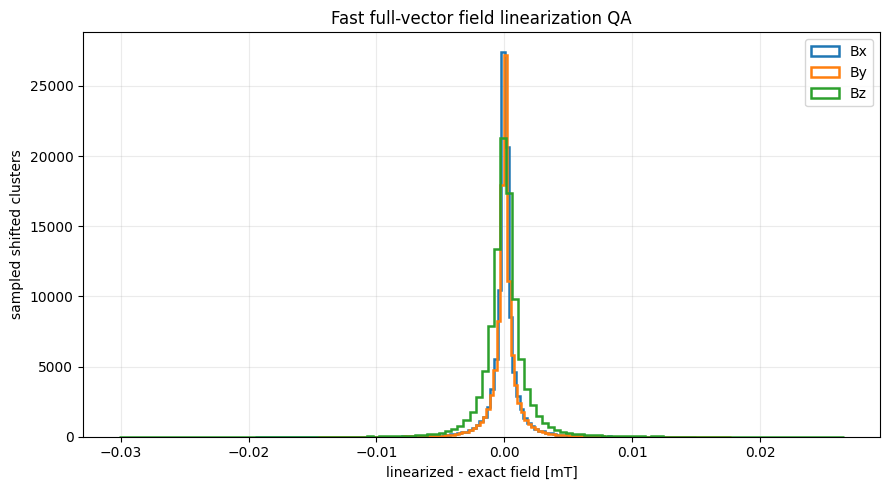

In [7]:
# ============================================================
# Fast-field approximation QA
# ============================================================

rng = np.random.default_rng(seed)
qa_count = min(100000, len(clusters))
qa_indices = rng.choice(len(clusters), size=qa_count, replace=False)

qa_xyz = cluster_xyz[qa_indices]
qa_b0 = cluster_field[qa_indices]
qa_gradient = cluster_field_gradient[qa_indices]

# Typical test shifts of order 2 mm, clipped at 5 mm.
qa_shift = np.clip(
    rng.normal(0.0, 0.20, size=(qa_count, 3)),
    -0.50,
    0.50,
)
qa_xyz_shifted = qa_xyz + qa_shift

qa_exact = np.column_stack(
    evaluate_field_map(
        qa_xyz_shifted[:, 0],
        qa_xyz_shifted[:, 1],
        qa_xyz_shifted[:, 2],
    )
)
qa_linearized = qa_b0 + np.einsum(
    'nij,nj->ni',
    qa_gradient,
    qa_shift,
)

qa_valid = (
    np.all(np.isfinite(qa_exact), axis=1)
    & np.all(np.isfinite(qa_linearized), axis=1)
)
qa_difference_millitesla = 1000.0 * (
    qa_linearized[qa_valid] - qa_exact[qa_valid]
)

print('Field linearization QA rows:', int(np.count_nonzero(qa_valid)))
print(
    'Field linearization mean error [mT] Bx,By,Bz:',
    np.mean(qa_difference_millitesla, axis=0),
)
print(
    'Field linearization RMS error [mT] Bx,By,Bz:',
    np.std(qa_difference_millitesla, axis=0),
)

plt.figure(figsize=(9, 5))
for component, label in enumerate(['Bx', 'By', 'Bz']):
    plt.hist(
        qa_difference_millitesla[:, component],
        bins=120,
        histtype='step',
        linewidth=1.8,
        label=label,
    )
plt.xlabel('linearized - exact field [mT]')
plt.ylabel('sampled shifted clusters')
plt.title('Fast full-vector field linearization QA')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# Full-field baseline convention
# ============================================================
#
# The current V0 reconstruction already supplies the baseline daughter momenta
# and candidate mass. Do NOT apply the old |<Bz>|/1.4 rescaling.
#
# The differentiable response is constructed so that zero DNN correction gives
# momentum_scale=1 and mass_after=selected_mass.

candidates['baseline_mass'] = candidates['selected_mass'].astype(np.float32)

print(
    'Baseline K0S mean mass:',
    float(
        candidates.loc[
            candidates['channel'] == 0,
            'baseline_mass',
        ].mean()
    ),
)


Baseline K0S mean mass: 0.4952790141105652


## 3. Build fixed-size candidate tensors

Each daughter keeps at most 48 cleaned TPC clusters, ordered inner-to-outer. K0S is the only training channel; \(\Lambda/\bar\Lambda\) are optional validation channels.


In [9]:
# ============================================================
# Joint candidate-to-cluster tensor construction
# ============================================================

FIELD_COMPONENT_COLUMNS = [
    'field_bx_tesla',
    'field_by_tesla',
    'field_bz_tesla',
]

FIELD_GRADIENT_COLUMNS = [
    f'd{field_name}_d{coordinate_name}_tesla_per_cm'
    for field_name in ['bx', 'by', 'bz']
    for coordinate_name in ['x', 'y', 'z']
]


def clean_track_clusters(frame):
    frame = frame.copy()

    finite_columns = [
        'cluster_r', 'cluster_phi', 'cluster_z',
        'residual_normal_xy',
        'normal_projection_r', 'normal_projection_rphi',
        'sigma_normal', 'residual_z', 'sigma_z_filled',
        *FIELD_COMPONENT_COLUMNS,
        *FIELD_GRADIENT_COLUMNS,
    ]

    finite = np.ones(len(frame), dtype=bool)
    for column in finite_columns:
        finite &= np.isfinite(frame[column].to_numpy(float))

    frame = frame.loc[finite]
    frame = frame.loc[frame['physical_side_z_valid'].astype(bool)]
    frame = frame.loc[(frame['layer'] >= 7) & (frame['layer'] <= 54)]
    frame = frame.loc[~frame['layer'].isin(excluded_layers)]

    frame = frame.loc[
        (np.abs(frame['residual_normal_xy']) < maximum_abs_residual_normal_cm)
        & (np.abs(frame['residual_z']) < maximum_abs_residual_z_cm)
    ]

    if use_recommended_clusters_only:
        frame = frame.loc[frame['recommended_for_reference_fit'].astype(bool)]

    if use_kalman_used_clusters_only:
        frame = frame.loc[frame['kalman_measurement_used'].astype(bool)]

    sort_columns = ['layer']
    if 'kalman_measurement_chi2' in frame.columns:
        sort_columns.append('kalman_measurement_chi2')

    frame = frame.sort_values(sort_columns)
    frame = frame.drop_duplicates('layer', keep='first')

    radial_modules = set(
        frame.loc[
            frame['radial_module'] >= 0,
            'radial_module',
        ].astype(int)
    )
    if len(radial_modules) < minimum_tpc_modules_per_track:
        return frame.iloc[0:0]

    radial_span_cm = (
        float(frame['cluster_r'].max())
        - float(frame['cluster_r'].min())
        if len(frame)
        else 0.0
    )
    if radial_span_cm < minimum_track_radial_span_cm:
        return frame.iloc[0:0]

    return frame.sort_values('layer').head(maximum_clusters)


def build_joint_channel_arrays(channel):
    candidate_frame = candidates.loc[candidates['channel'] == channel].copy()

    candidate_frame = candidate_frame.loc[candidate_frame['pass_cut07'].astype(bool) & candidate_frame['pass_pid'].astype(bool)]

    channel_clusters = clusters.loc[clusters['channel'] == channel]

    grouped = {
        key: value
        for key, value in channel_clusters.groupby(
            ['candidate_id', 'daughter'],
            sort=False,
        )
    }

    records = []
    for row in candidate_frame.itertuples(index=False):
        key1 = (row.candidate_id, 1)
        key2 = (row.candidate_id, 2)

        if key1 not in grouped or key2 not in grouped:
            continue

        first = clean_track_clusters(grouped[key1])
        second = clean_track_clusters(grouped[key2])

        if (
            len(first) < minimum_clusters_per_track
            or len(second) < minimum_clusters_per_track
        ):
            continue

        first_side = int(round(float(row.side1)))
        second_side = int(round(float(row.side2)))

        if not np.all(first['side'].to_numpy(int) == first_side):
            continue
        if not np.all(second['side'].to_numpy(int) == second_side):
            continue

        records.append((row, first, second))

    if not records:
        raise RuntimeError(f'No usable candidates for channel={channel}')

    number = len(records)
    shape = (number, maximum_clusters)

    float_track_fields = [
        'r', 'phi_cluster', 'z_cluster',
        'res_normal',
        'normal_projection_r', 'normal_projection_rphi',
        'sigma_normal', 'res_z', 'sigma_z', 'mask',
        'field_bx', 'field_by', 'field_bz',
        'dbx_dx', 'dbx_dy', 'dbx_dz',
        'dby_dx', 'dby_dy', 'dby_dz',
        'dbz_dx', 'dbz_dy', 'dbz_dz',
    ]

    output = {}
    for suffix in ['1', '2']:
        for field in float_track_fields:
            output[f'{field}{suffix}'] = np.zeros(
                shape,
                dtype=np.float32,
            )

    scalar_float_names = [
        'selected_mass', 'baseline_mass', 'pair_pt',
        'pca_x', 'pca_y', 'pca_z',
        'charge1', 'charge2',
        'pt1', 'pt2', 'phi1', 'phi2', 'eta1', 'eta2',
        'px1', 'py1', 'pz1', 'px2', 'py2', 'pz2',
    ]

    for name in scalar_float_names:
        output[name] = np.zeros(number, dtype=np.float32)

    output['candidate_id'] = np.zeros(number, dtype=np.int64)
    output['event_parity'] = np.zeros(number, dtype=np.int64)
    output['side1'] = np.zeros(number, dtype=np.int64)
    output['side2'] = np.zeros(number, dtype=np.int64)
    output['same_side'] = np.zeros(number, dtype=np.int64)
    output['channel'] = np.full(number, channel, dtype=np.int64)

    def fill_track(index, frame, suffix):
        count = len(frame)

        mappings = {
            f'r{suffix}': 'cluster_r',
            f'phi_cluster{suffix}': 'cluster_phi',
            f'z_cluster{suffix}': 'cluster_z',
            f'res_normal{suffix}': 'residual_normal_xy',
            f'normal_projection_r{suffix}': 'normal_projection_r',
            f'normal_projection_rphi{suffix}': 'normal_projection_rphi',
            f'sigma_normal{suffix}': 'sigma_normal',
            f'res_z{suffix}': 'residual_z',
            f'sigma_z{suffix}': 'sigma_z_filled',
            f'field_bx{suffix}': 'field_bx_tesla',
            f'field_by{suffix}': 'field_by_tesla',
            f'field_bz{suffix}': 'field_bz_tesla',
            f'dbx_dx{suffix}': 'dbx_dx_tesla_per_cm',
            f'dbx_dy{suffix}': 'dbx_dy_tesla_per_cm',
            f'dbx_dz{suffix}': 'dbx_dz_tesla_per_cm',
            f'dby_dx{suffix}': 'dby_dx_tesla_per_cm',
            f'dby_dy{suffix}': 'dby_dy_tesla_per_cm',
            f'dby_dz{suffix}': 'dby_dz_tesla_per_cm',
            f'dbz_dx{suffix}': 'dbz_dx_tesla_per_cm',
            f'dbz_dy{suffix}': 'dbz_dy_tesla_per_cm',
            f'dbz_dz{suffix}': 'dbz_dz_tesla_per_cm',
        }

        for output_name, column in mappings.items():
            output[output_name][index, :count] = (
                frame[column].to_numpy(np.float32)
            )

        output[f'mask{suffix}'][index, :count] = 1.0

    for index, (row, first, second) in enumerate(records):
        for name in scalar_float_names:
            output[name][index] = getattr(row, name)

        output['candidate_id'][index] = int(row.candidate_id)
        output['event_parity'][index] = int(row.event_parity)
        output['side1'][index] = int(row.side1)
        output['side2'][index] = int(row.side2)
        output['same_side'][index] = int(bool(row.same_side))

        fill_track(index, first, '1')
        fill_track(index, second, '2')

    output['pair_weight'] = np.ones(number, dtype=np.float32)

    # Filled after the fixed pre-training K0S mass model is fitted.
    output['signal_probability'] = np.ones(number, dtype=np.float32)

    print(
        f'channel={channel}: {number} usable candidates; '
        f'same-side fraction={np.mean(output["same_side"]):.4f}'
    )

    for side in [0, 1]:
        daughter_count = (
            np.count_nonzero(output['side1'] == side)
            + np.count_nonzero(output['side2'] == side)
        )
        print(f'  daughter tracks on side {side}: {daughter_count}')

    return output


kshort_arrays = build_joint_channel_arrays(0)

validation_arrays = {}
for channel in [1, 2]:
    try:
        validation_arrays[channel] = build_joint_channel_arrays(channel)
    except RuntimeError as error:
        print(error)


channel=0: 41643 usable candidates; same-side fraction=0.9740
  daughter tracks on side 0: 42074
  daughter tracks on side 1: 41212
channel=1: 2499 usable candidates; same-side fraction=0.9844
  daughter tracks on side 0: 2489
  daughter tracks on side 1: 2509
channel=2: 2457 usable candidates; same-side fraction=0.9837
  daughter tracks on side 0: 2552
  daughter tracks on side 1: 2362


In [10]:
# ============================================================
# Cache joint arrays
# ============================================================

kshort_npz_file = cache_dir / 'kshort_joint.npz'
np.savez_compressed(kshort_npz_file, **kshort_arrays)
print('Wrote:', kshort_npz_file)

validation_npz_files = {}
for channel, arrays in validation_arrays.items():
    output_file = cache_dir / f'channel{channel}_joint.npz'
    np.savez_compressed(output_file, **arrays)
    validation_npz_files[channel] = output_file
    print('Wrote:', output_file)


def load_npz_dictionary(path):
    with np.load(path, allow_pickle=False) as input_file:
        return {
            key: input_file[key]
            for key in input_file.files
        }


Wrote: output/v0_spatial_calibration_v11_radial_short/tensor_cache/kshort_joint.npz
Wrote: output/v0_spatial_calibration_v11_radial_short/tensor_cache/channel1_joint.npz
Wrote: output/v0_spatial_calibration_v11_radial_short/tensor_cache/channel2_joint.npz


In [11]:
# ============================================================
# PyTorch datasets
# ============================================================

class CandidateDataset(Dataset):
    def __init__(self, arrays, indices):
        self.data = {}
        number_of_candidates = len(arrays['candidate_id'])

        for key, values in arrays.items():
            if (
                isinstance(values, np.ndarray)
                and len(values) == number_of_candidates
            ):
                self.data[key] = torch.from_numpy(values[indices])

    def __len__(self):
        return len(self.data['candidate_id'])

    def __getitem__(self, index):
        return {
            key: value[index]
            for key, value in self.data.items()
        }


class ResidualDataset(Dataset):
    def __init__(self, arrays):
        self.data = {
            key: torch.from_numpy(value)
            for key, value in arrays.items()
        }

    def __len__(self):
        return len(self.data['r'])

    def __getitem__(self, index):
        return {
            key: value[index]
            for key, value in self.data.items()
        }


def flatten_training_clusters_for_side(arrays, candidate_indices, side):
    output_lists = {
        key: []
        for key in [
            'r', 'phi', 'z',
            'res_normal',
            'normal_projection_r', 'normal_projection_rphi',
            'sigma_normal',
            'res_z', 'sigma_z',
        ]
    }

    for suffix in ['1', '2']:
        daughter_on_side = (
            arrays[f'side{suffix}'][candidate_indices] == side
        )
        selected_candidate_indices = candidate_indices[daughter_on_side]

        if len(selected_candidate_indices) == 0:
            continue

        mask = (
            arrays[f'mask{suffix}'][selected_candidate_indices] > 0.5
        )

        source_names = {
            'r': f'r{suffix}',
            'phi': f'phi_cluster{suffix}',
            'z': f'z_cluster{suffix}',
            'res_normal': f'res_normal{suffix}',
            'normal_projection_r': f'normal_projection_r{suffix}',
            'normal_projection_rphi': f'normal_projection_rphi{suffix}',
            'sigma_normal': f'sigma_normal{suffix}',
            'res_z': f'res_z{suffix}',
            'sigma_z': f'sigma_z{suffix}',
        }

        for output_name, source_name in source_names.items():
            output_lists[output_name].append(
                arrays[source_name][selected_candidate_indices][mask]
                .astype(np.float32)
            )

    output = {}
    for key, pieces in output_lists.items():
        if not pieces:
            raise RuntimeError(f'No residual clusters for side {side}')
        output[key] = np.concatenate(pieces).astype(np.float32)

    return output


## 4. Full-field momentum response

For a proposed spatial correction we recalculate only the **relative** trajectory curvature response. At zero correction the original reconstructed momentum is recovered. Stage 1 sets `direction_correction_strength = 0`, so it cannot use a momentum-direction/DCA-like change as a fitting knob.


In [12]:
# ============================================================
# Differentiable full-field response
# ============================================================

def raw_position_from_cylindrical(r, phi, z):
    return torch.stack([r * torch.cos(phi), r * torch.sin(phi), z], dim=-1)


def corrected_field_from_raw(raw_position, corrected_position, raw_field, raw_gradient):
    if field_evaluation_mode == 'linearized':
        return raw_field + torch.einsum('...ij,...j->...i', raw_gradient, corrected_position - raw_position)
    if field_evaluation_mode == 'torch_trilinear':
        return torch_trilinear_field(corrected_position)
    raise ValueError(f'Unknown field_evaluation_mode={field_evaluation_mode!r}')


def estimate_q_over_p_from_trajectory(position, field, mask):
    segment = position[:, 1:, :] - position[:, :-1, :]
    segment_mask = mask[:, 1:] * mask[:, :-1]
    ds = torch.sqrt(torch.clamp(torch.sum(segment * segment, dim=-1), min=1.0e-10))
    tangent = segment / ds[..., None]

    bend_mask = segment_mask[:, 1:] * segment_mask[:, :-1]
    ds_mid = 0.5 * (ds[:, 1:] + ds[:, :-1])
    du_ds = (tangent[:, 1:, :] - tangent[:, :-1, :]) / torch.clamp(ds_mid[..., None], min=1.0e-6)

    tangent_mid = tangent[:, 1:, :] + tangent[:, :-1, :]
    tangent_mid = tangent_mid / torch.sqrt(torch.clamp(torch.sum(tangent_mid * tangent_mid, dim=-1), min=1.0e-10))[..., None]
    field_mid = field[:, 1:-1, :]
    lorentz_direction = torch.cross(tangent_mid, field_mid, dim=-1)

    dot_term = torch.sum(du_ds * lorentz_direction, dim=-1)
    lorentz_norm2 = torch.sum(lorentz_direction * lorentz_direction, dim=-1)
    weight = bend_mask * torch.clamp(ds_mid, min=0.0)

    numerator = torch.sum(weight * dot_term, dim=1)
    denominator = lorentz_curvature_constant * torch.sum(weight * lorentz_norm2, dim=1)
    q_over_p = numerator / torch.clamp(denominator, min=1.0e-10)

    effective_bends = torch.sum(bend_mask, dim=1)
    valid = (effective_bends >= 3) & torch.isfinite(q_over_p) & (torch.abs(q_over_p) > 1.0e-6)
    return q_over_p, valid


def inner_tangent(position, mask):
    segment = position[:, 1:, :] - position[:, :-1, :]
    segment_mask = mask[:, 1:] * mask[:, :-1]
    unit = segment / torch.sqrt(torch.clamp(torch.sum(segment * segment, dim=-1), min=1.0e-10))[..., None]
    index = torch.arange(unit.shape[1], dtype=unit.dtype, device=unit.device)[None, :]
    weight = segment_mask * torch.exp(-index / 2.0)
    tangent = torch.sum(weight[..., None] * unit, dim=1)
    return tangent / torch.sqrt(torch.clamp(torch.sum(tangent * tangent, dim=-1), min=1.0e-10))[..., None]


def refit_track_full_field(model, r, phi, z, mask, charge, original_pt, original_phi, original_eta, raw_field, raw_field_gradient):
    raw_position = raw_position_from_cylindrical(r, phi, z)
    delta_r, r_delta_phi, delta_z = model(r, phi, z)

    corrected_r = r - delta_r * mask
    corrected_phi = phi - (r_delta_phi / torch.clamp(r, min=1.0e-6)) * mask
    corrected_z = z - delta_z * mask
    corrected_position = raw_position_from_cylindrical(corrected_r, corrected_phi, corrected_z)
    corrected_field = corrected_field_from_raw(raw_position, corrected_position, raw_field, raw_field_gradient)

    raw_q_over_p, raw_valid = estimate_q_over_p_from_trajectory(raw_position, raw_field, mask)
    corrected_q_over_p, corrected_valid = estimate_q_over_p_from_trajectory(corrected_position, corrected_field, mask)

    relative_scale = torch.abs(raw_q_over_p) / torch.clamp(torch.abs(corrected_q_over_p), min=1.0e-6)
    valid_scale = raw_valid & corrected_valid & torch.isfinite(relative_scale)
    relative_scale = torch.where(valid_scale, relative_scale, torch.ones_like(relative_scale))
    relative_scale = torch.clamp(relative_scale, min=minimum_refit_scale, max=maximum_refit_scale)
    relative_scale = 1.0 + momentum_scale_response_strength * (relative_scale - 1.0)

    original_momentum = torch.stack([
        original_pt * torch.cos(original_phi),
        original_pt * torch.sin(original_phi),
        original_pt * torch.sinh(original_eta),
    ], dim=1)
    original_p = torch.sqrt(torch.clamp(torch.sum(original_momentum * original_momentum, dim=1), min=1.0e-10))
    original_unit = original_momentum / original_p[:, None]

    if direction_correction_strength != 0.0:
        raw_inner = inner_tangent(raw_position, mask)
        corrected_inner = inner_tangent(corrected_position, mask)
        orientation = torch.where(torch.sum(raw_inner * original_unit, dim=1) >= 0.0, torch.ones_like(original_p), -torch.ones_like(original_p))
        direction_delta = corrected_inner * orientation[:, None] - raw_inner * orientation[:, None]
        corrected_unit = original_unit + direction_correction_strength * direction_delta
        corrected_unit = corrected_unit / torch.sqrt(torch.clamp(torch.sum(corrected_unit * corrected_unit, dim=1), min=1.0e-10))[:, None]
    else:
        corrected_unit = original_unit

    corrected_p = original_p * relative_scale
    corrected_momentum = corrected_unit * corrected_p[:, None]
    corrected_pt = torch.sqrt(torch.clamp(corrected_momentum[:, 0] ** 2 + corrected_momentum[:, 1] ** 2, min=0.0))

    return {
        'momentum': corrected_momentum,
        'pt': corrected_pt,
        'momentum_scale': relative_scale,
        'qop_valid': valid_scale,
        'delta_r': delta_r,
        'r_delta_phi': r_delta_phi,
        'delta_z': delta_z,
    }


def scatter_track_results(pieces, number_of_rows):
    all_indices = torch.cat([item[0] for item in pieces])
    order = torch.argsort(all_indices)
    output = {}
    for key in pieces[0][1]:
        output[key] = torch.cat([item[1][key] for item in pieces], dim=0)[order]
    if len(all_indices) != number_of_rows:
        raise RuntimeError('Per-side refit did not cover the complete candidate batch')
    return output


def refit_track_by_side(joint_model, r, phi, z, mask, charge, original_pt, original_phi, original_eta, track_side, raw_field, raw_field_gradient):
    pieces = []
    side_integer = track_side.to(torch.long)
    for side in [0, 1]:
        indices = torch.nonzero(side_integer == side, as_tuple=False)[:, 0]
        if len(indices) == 0:
            continue
        result = refit_track_full_field(
            joint_model.side_models[str(side)], r[indices], phi[indices], z[indices], mask[indices],
            charge[indices], original_pt[indices], original_phi[indices], original_eta[indices],
            raw_field[indices], raw_field_gradient[indices],
        )
        pieces.append((indices, result))
    if not pieces:
        raise RuntimeError('No valid side found in candidate batch')
    return scatter_track_results(pieces, len(track_side))


def invariant_mass(momentum1, momentum2, mass1, mass2):
    energy1 = torch.sqrt(torch.sum(momentum1 ** 2, dim=1) + mass1 ** 2)
    energy2 = torch.sqrt(torch.sum(momentum2 ** 2, dim=1) + mass2 ** 2)
    total = momentum1 + momentum2
    return torch.sqrt(torch.clamp((energy1 + energy2) ** 2 - torch.sum(total ** 2, dim=1), min=0.0))


def track_field_tensors(batch, suffix):
    field = torch.stack([batch[f'field_bx{suffix}'], batch[f'field_by{suffix}'], batch[f'field_bz{suffix}']], dim=-1)
    gradient = torch.stack([
        batch[f'dbx_dx{suffix}'], batch[f'dbx_dy{suffix}'], batch[f'dbx_dz{suffix}'],
        batch[f'dby_dx{suffix}'], batch[f'dby_dy{suffix}'], batch[f'dby_dz{suffix}'],
        batch[f'dbz_dx{suffix}'], batch[f'dbz_dy{suffix}'], batch[f'dbz_dz{suffix}'],
    ], dim=-1)
    return field, gradient.reshape(*gradient.shape[:-1], 3, 3)


def correct_batch(model, batch, channel=0):
    field1, gradient1 = track_field_tensors(batch, '1')
    field2, gradient2 = track_field_tensors(batch, '2')

    first = refit_track_by_side(
        model, batch['r1'], batch['phi_cluster1'], batch['z_cluster1'], batch['mask1'], batch['charge1'],
        batch['pt1'], batch['phi1'], batch['eta1'], batch['side1'], field1, gradient1,
    )
    second = refit_track_by_side(
        model, batch['r2'], batch['phi_cluster2'], batch['z_cluster2'], batch['mask2'], batch['charge2'],
        batch['pt2'], batch['phi2'], batch['eta2'], batch['side2'], field2, gradient2,
    )

    if channel == 0:
        mass1 = torch.full_like(batch['charge1'], pion_mass)
        mass2 = torch.full_like(batch['charge2'], pion_mass)
    elif channel == 1:
        mass1 = torch.where(batch['charge1'] > 0, torch.full_like(batch['charge1'], proton_mass), torch.full_like(batch['charge1'], pion_mass))
        mass2 = torch.where(batch['charge2'] > 0, torch.full_like(batch['charge2'], proton_mass), torch.full_like(batch['charge2'], pion_mass))
    else:
        mass1 = torch.where(batch['charge1'] < 0, torch.full_like(batch['charge1'], proton_mass), torch.full_like(batch['charge1'], pion_mass))
        mass2 = torch.where(batch['charge2'] < 0, torch.full_like(batch['charge2'], proton_mass), torch.full_like(batch['charge2'], pion_mass))

    return first, second, invariant_mass(first['momentum'], second['momentum'], mass1, mass2)


## 5. Freeze the K0S signal core

The signal/background model is fitted **before** calibration. Candidate weights are then frozen, so the optimizer cannot move background into the peak to improve its loss.


Frozen K0S mass models:
{
  "global": {
    "label": "global",
    "signal_fraction": 0.7314903531411037,
    "mean": 0.4959894833046264,
    "sigma": 0.008152788461683035,
    "slope": -0.48457188997335954,
    "fit_nll": -57496.32798115036,
    "n_candidates": 20767,
    "mass_minimum": 0.44,
    "mass_maximum": 0.56
  },
  "pt_bins": [
    {
      "pt_low": 0.5,
      "pt_high": 0.800000011920929,
      "model": {
        "label": "0.5-0.8",
        "signal_fraction": 0.75,
        "mean": 0.4940278790052042,
        "sigma": 0.00560463117359196,
        "slope": -0.3470267404288901,
        "fit_nll": -5547.583014130614,
        "n_candidates": 1803,
        "mass_minimum": 0.44,
        "mass_maximum": 0.56
      }
    },
    {
      "pt_low": 0.800000011920929,
      "pt_high": 1.100000023841858,
      "model": {
        "label": "0.8-1.1",
        "signal_fraction": 0.75,
        "mean": 0.4951613733428885,
        "sigma": 0.00597942254726611,
        "slope": -0.27821250501347

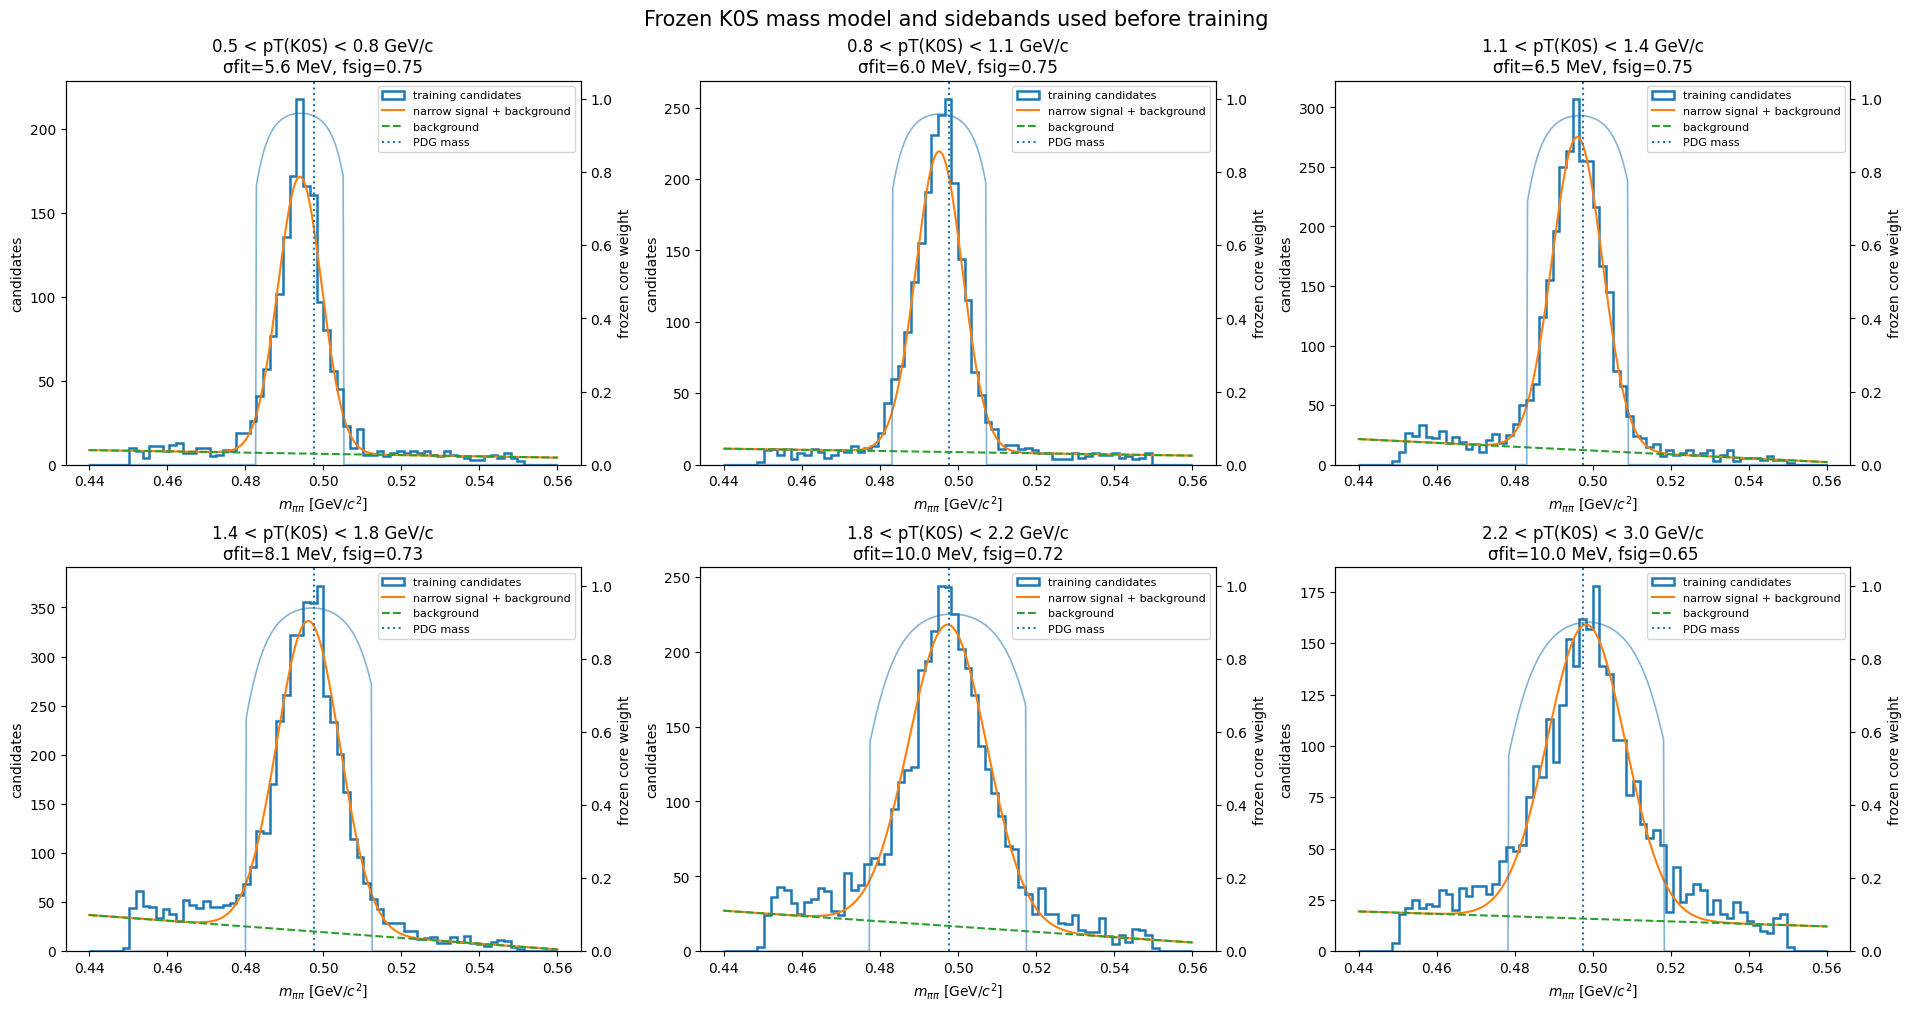

In [13]:
# ============================================================
# Frozen narrow K0S mass model: shared mass + charge gate
# ============================================================
#
# The same frozen baseline-mass core gates BOTH the mass and charge-balance losses.
# Nothing is recomputed from corrected mass, so the network cannot move background
# into the peak to gain charge-balance weight.

from scipy.stats import norm as scipy_norm


def _normalized_linear_background(mass, slope, low=min_k0s_mass, high=max_k0s_mass):
    mass = np.asarray(mass, dtype=np.float64)
    center = 0.5 * (low + high)
    half_width = 0.5 * (high - low)
    u = (mass - center) / max(half_width, 1.0e-12)
    density = np.clip(1.0 + slope * u, 1.0e-8, None)
    return density / (high - low)


def fixed_mass_components(mass_values, model):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    low = model['mass_minimum']
    high = model['mass_maximum']
    signal = scipy_norm.pdf(mass_values, loc=model['mean'], scale=model['sigma'])
    norm_window = scipy_norm.cdf(high, loc=model['mean'], scale=model['sigma']) - scipy_norm.cdf(low, loc=model['mean'], scale=model['sigma'])
    signal = signal / max(norm_window, 1.0e-12)
    background = _normalized_linear_background(mass_values, model['slope'], low, high)
    signal_weighted = model['signal_fraction'] * signal
    background_weighted = (1.0 - model['signal_fraction']) * background
    return signal_weighted, background_weighted


def fit_fixed_k0s_mass_model(mass_values, label='global'):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    mass_values = mass_values[np.isfinite(mass_values) & (mass_values >= min_k0s_mass) & (mass_values <= max_k0s_mass)]

    if mass_values.size < 100:
        raise RuntimeError(f'Not enough K0S candidates to fit mass model {label}: {mass_values.size}')

    def nll(theta):
        fraction, mean, sigma, slope = theta
        model = {
            'signal_fraction': fraction,
            'mean': mean,
            'sigma': sigma,
            'slope': slope,
            'mass_minimum': min_k0s_mass,
            'mass_maximum': max_k0s_mass,
        }
        signal_weighted, background_weighted = fixed_mass_components(mass_values, model)
        return -np.log(np.clip(signal_weighted + background_weighted, 1.0e-15, None)).sum()

    initial = np.array([0.45, pdg_kshort_mass, 0.008, 0.0], dtype=np.float64)
    fit = minimize(
        nll,
        initial,
        method='L-BFGS-B',
        bounds=[
            (k0s_mass_fit_signal_fraction_min, k0s_mass_fit_signal_fraction_max),
            (k0s_mass_fit_mean_min, k0s_mass_fit_mean_max),
            (k0s_mass_fit_sigma_min_gev, k0s_mass_fit_sigma_max_gev),
            (-0.90, 0.90),
        ],
    )

    if not fit.success:
        raise RuntimeError(f'K0S mass fit failed for {label}: {fit.message}')

    fraction, mean, sigma, slope = fit.x
    return {
        'label': label,
        'signal_fraction': float(fraction),
        'mean': float(mean),
        'sigma': float(sigma),
        'slope': float(slope),
        'fit_nll': float(fit.fun),
        'n_candidates': int(mass_values.size),
        'mass_minimum': float(min_k0s_mass),
        'mass_maximum': float(max_k0s_mass),
    }


def fixed_signal_probability(mass_values, model):
    signal_weighted, background_weighted = fixed_mass_components(mass_values, model)
    probability = signal_weighted / np.clip(signal_weighted + background_weighted, 1.0e-15, None)
    return np.clip(probability, minimum_signal_probability_for_physics, 1.0).astype(np.float32)


training_mass_mask = kshort_arrays['event_parity'].astype(np.int64) == training_parity
fixed_mass_models = {'global': fit_fixed_k0s_mass_model(kshort_arrays['baseline_mass'][training_mass_mask], 'global'), 'pt_bins': []}

for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
    selected = training_mass_mask & (kshort_arrays['pair_pt'] >= lower) & (kshort_arrays['pair_pt'] < upper)
    if np.count_nonzero(selected) >= k0s_mass_model_minimum_candidates_per_pt_bin:
        model = fit_fixed_k0s_mass_model(kshort_arrays['baseline_mass'][selected], f'{lower:.1f}-{upper:.1f}')
    else:
        model = dict(fixed_mass_models['global'])
        model['label'] = f'{lower:.1f}-{upper:.1f} fallback-global'
        model['n_candidates'] = int(np.count_nonzero(selected))
    fixed_mass_models['pt_bins'].append({'pt_low': float(lower), 'pt_high': float(upper), 'model': model})

# Backward-compatible name used in checkpoint metadata later.
fixed_mass_model = fixed_mass_models['global']


def assign_frozen_mass_weights(mass_values, pair_pt):
    mass_values = np.asarray(mass_values, dtype=np.float64)
    pair_pt = np.asarray(pair_pt, dtype=np.float64)
    probability = fixed_signal_probability(mass_values, fixed_mass_models['global'])
    core_weight = np.zeros(len(mass_values), dtype=np.float32)
    model_mean = np.full(len(mass_values), fixed_mass_models['global']['mean'], dtype=np.float32)
    model_sigma = np.full(len(mass_values), fixed_mass_models['global']['sigma'], dtype=np.float32)

    for item in fixed_mass_models['pt_bins']:
        lower = item['pt_low']
        upper = item['pt_high']
        model = item['model']
        selected = (pair_pt >= lower) & (pair_pt < upper)
        if not np.any(selected):
            continue
        probability[selected] = fixed_signal_probability(mass_values[selected], model)
        model_mean[selected] = model['mean']
        model_sigma[selected] = model['sigma']

    core = np.abs(mass_values - model_mean) <= k0s_mass_core_nsigma * model_sigma
    core_weight[core] = probability[core]
    return probability.astype(np.float32), core_weight, model_mean, model_sigma


(
    kshort_arrays['signal_probability'],
    kshort_arrays['mass_core_weight'],
    kshort_arrays['mass_model_mean'],
    kshort_arrays['mass_model_sigma'],
) = assign_frozen_mass_weights(kshort_arrays['baseline_mass'], kshort_arrays['pair_pt'])

# Fail fast before expensive training if the fit still labels sidebands as signal.
train_mass = kshort_arrays['baseline_mass'][training_mass_mask]
train_probability = kshort_arrays['signal_probability'][training_mass_mask]
global_mean = fixed_mass_models['global']['mean']
global_sigma = fixed_mass_models['global']['sigma']
peak_selection = np.abs(train_mass - global_mean) < 1.5 * global_sigma
sideband_selection = np.abs(train_mass - global_mean) > max(3.0 * global_sigma, 0.025)

peak_probability = float(np.mean(train_probability[peak_selection])) if np.any(peak_selection) else np.nan
sideband_probability = float(np.mean(train_probability[sideband_selection])) if np.any(sideband_selection) else np.nan

print('Frozen K0S mass models:')
print(json.dumps(fixed_mass_models, indent=2))
print('Frozen signal probability: min/mean/max =', float(kshort_arrays['signal_probability'].min()), float(kshort_arrays['signal_probability'].mean()), float(kshort_arrays['signal_probability'].max()))
print('Peak mean P(signal) =', peak_probability)
print('Sideband mean P(signal) =', sideband_probability)
print('Mass-core candidates =', int(np.count_nonzero(kshort_arrays['mass_core_weight'] > 0)), '/', len(kshort_arrays['mass_core_weight']))

if np.isfinite(sideband_probability) and sideband_probability > maximum_allowed_sideband_signal_probability:
    raise RuntimeError(f'Unsafe K0S mass model: sideband P(signal)={sideband_probability:.3f} > {maximum_allowed_sideband_signal_probability:.3f}')
if np.isfinite(peak_probability) and np.isfinite(sideband_probability) and peak_probability - sideband_probability < minimum_peak_minus_sideband_probability:
    raise RuntimeError(f'Unsafe K0S mass model: peak-sideband probability separation is only {peak_probability-sideband_probability:.3f}')

# Refresh the cache with the frozen mass weights.
np.savez_compressed(cache_dir / 'kshort_joint.npz', **kshort_arrays)

# QA: raw mass spectrum plus narrow fitted model in every mother-pT bin.
figure, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True)
axes = axes.ravel()

for axis, item in zip(axes, fixed_mass_models['pt_bins']):
    lower = item['pt_low']
    upper = item['pt_high']
    model = item['model']
    selected = training_mass_mask & (kshort_arrays['pair_pt'] >= lower) & (kshort_arrays['pair_pt'] < upper)
    values = kshort_arrays['baseline_mass'][selected]
    counts, edges, _ = axis.hist(values, bins=70, range=(min_k0s_mass, max_k0s_mass), histtype='step', linewidth=1.8, label='training candidates')
    grid = np.linspace(min_k0s_mass, max_k0s_mass, 600)
    signal_weighted, background_weighted = fixed_mass_components(grid, model)
    bin_width = edges[1] - edges[0]
    normalization = len(values) * bin_width
    axis.plot(grid, normalization * (signal_weighted + background_weighted), label='narrow signal + background')
    axis.plot(grid, normalization * background_weighted, linestyle='--', label='background')
    probability_grid = fixed_signal_probability(grid, model)
    core_grid = np.abs(grid - model['mean']) <= k0s_mass_core_nsigma * model['sigma']
    axis2 = axis.twinx()
    axis2.plot(grid, probability_grid * core_grid, alpha=0.55, linewidth=1.2, label='charge/mass core weight')
    axis2.set_ylim(0.0, 1.05)
    axis2.set_ylabel('frozen core weight')
    axis.axvline(pdg_kshort_mass, linestyle=':', linewidth=1.5, label='PDG mass')
    axis.set_title(f'{lower:.1f} < pT(K0S) < {upper:.1f} GeV/c\nσfit={1000*model["sigma"]:.1f} MeV, fsig={model["signal_fraction"]:.2f}')
    axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axis.set_ylabel('candidates')
    axis.legend(fontsize=8)

figure.suptitle('Frozen K0S mass model and sidebands used before training', fontsize=15)
plt.show()


## 6. Stage 1 — radial stretch only

The trainable model has **one parameter**, \(s\). It is shared by both TPC sides and bounded to the configured range.

The loss is intentionally simple:

\[
L_1 =
L_{m(p_T)}
+0.15\,L_{m,\mathrm{incl}}
+0.05\,L_{\mathrm{width}}
+0.03\,L_{\mathrm{residual}}
+0.005\,L_s.
\]

Charge balance is **not** optimized in Stage 1; it is checked afterwards.


In [14]:
# ============================================================
# Stage 1: one global radial stretch
# ============================================================

class RadialSideView:
    def __init__(self, parent):
        self.parent = parent

    def __call__(self, r, phi, z):
        return self.parent(r, phi, z)


class RadialStretchModel(nn.Module):
    def __init__(self, initial_fraction=0.0):
        super().__init__()
        self.stretch_fraction = nn.Parameter(torch.tensor(float(initial_fraction), dtype=torch.float32))
        self.side_models = {'0': RadialSideView(self), '1': RadialSideView(self)}

    def bounded_stretch(self):
        return torch.clamp(self.stretch_fraction, -stage1_max_abs_stretch_fraction, stage1_max_abs_stretch_fraction)

    def forward(self, r, phi, z):
        stretch = self.bounded_stretch()
        delta_r = -stretch * (r - stage1_pivot_r_cm)
        zero = torch.zeros_like(delta_r)
        return delta_r, zero, zero

    def set_stretch(self, value):
        with torch.no_grad():
            self.stretch_fraction.fill_(float(value))

    def value(self):
        return float(self.bounded_stretch().detach().cpu())


def torch_weighted_mean_variance(values, weights):
    weight_sum = torch.clamp(weights.sum(), min=1.0e-12)
    mean = torch.sum(weights * values) / weight_sum
    variance = torch.sum(weights * (values - mean) ** 2) / weight_sum
    neff = weight_sum ** 2 / torch.clamp(torch.sum(weights ** 2), min=1.0e-12)
    return mean, variance, neff


def stage1_mass_loss(corrected_mass, batch):
    weights_all = batch['pair_weight'] * batch['mass_core_weight']
    total = corrected_mass.new_zeros(())
    total_weight = corrected_mass.new_zeros(())
    width_sum = corrected_mass.new_zeros(())

    for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
        selection = (batch['pair_pt'] >= float(lower)) & (batch['pair_pt'] < float(upper))
        weights = weights_all * selection.to(weights_all.dtype)
        corrected_mean, corrected_variance, neff = torch_weighted_mean_variance(corrected_mass, weights)
        _, baseline_variance, _ = torch_weighted_mean_variance(batch['baseline_mass'], weights)
        active = (neff >= pt_mass_scale_minimum_effective_entries).to(corrected_mass.dtype)

        mean_loss = ((corrected_mean - pdg_kshort_mass) / stage1_mass_scale_gev) ** 2
        width_ratio = torch.sqrt(torch.clamp(corrected_variance / torch.clamp(baseline_variance, min=1.0e-8), min=0.0))
        width_loss = width_ratio ** 2
        center = 0.5 * (float(lower) + float(upper))
        priority = min((center / stage1_pt_priority_reference_gev) ** stage1_pt_priority_power, stage1_pt_priority_maximum)

        total = total + active * float(priority) * mean_loss
        width_sum = width_sum + active * float(priority) * width_loss
        total_weight = total_weight + active * float(priority)

    total_weight = torch.clamp(total_weight, min=1.0)
    return total / total_weight, width_sum / total_weight


def stage1_inclusive_mass_loss(corrected_mass, batch):
    weights = batch['pair_weight'] * batch['mass_core_weight']
    corrected_mean, _, _ = torch_weighted_mean_variance(corrected_mass, weights)
    return ((corrected_mean - pdg_kshort_mass) / stage1_mass_scale_gev) ** 2


def masked_huber(prediction, target, sigma, mask):
    normalized = (prediction - target) / torch.clamp(sigma, min=1.0e-4)
    loss = F.smooth_l1_loss(normalized, torch.zeros_like(normalized), reduction='none')
    return torch.sum(loss * mask) / torch.clamp(mask.sum(), min=1.0)


def stage1_residual_loss(model, batch):
    weighted_losses = []
    weights = []

    for suffix in ['1', '2']:
        for side in [0, 1]:
            selected = batch[f'side{suffix}'].to(torch.long) == side
            if not torch.any(selected):
                continue
            r = batch[f'r{suffix}'][selected]
            phi = batch[f'phi_cluster{suffix}'][selected]
            z = batch[f'z_cluster{suffix}'][selected]
            mask = batch[f'mask{suffix}'][selected]
            delta_r, _, _ = model.side_models[str(side)](r, phi, z)
            prediction = delta_r * batch[f'normal_projection_r{suffix}'][selected]
            loss = masked_huber(prediction, batch[f'res_normal{suffix}'][selected], batch[f'sigma_normal{suffix}'][selected], mask)
            weight = mask.sum().detach()
            weighted_losses.append(loss * weight)
            weights.append(weight)

    if not weighted_losses:
        return torch.zeros((), dtype=model.stretch_fraction.dtype)
    return sum(weighted_losses) / torch.clamp(torch.stack(weights).sum(), min=1.0)


def stage1_batch_loss(model, batch):
    _, _, corrected_mass = correct_batch(model, batch, channel=0)
    pt_mass, width = stage1_mass_loss(corrected_mass, batch)
    inclusive_mass = stage1_inclusive_mass_loss(corrected_mass, batch)
    residual = stage1_residual_loss(model, batch)
    stretch_prior = (model.bounded_stretch() / stage1_max_abs_stretch_fraction) ** 2

    total = (
        stage1_pt_mass_weight * pt_mass
        + stage1_inclusive_mass_weight * inclusive_mass
        + stage1_width_weight * width
        + stage1_residual_weight * residual
        + stage1_stretch_prior_weight * stretch_prior
    )
    return total, {
        'pt_mass': pt_mass,
        'inclusive_mass': inclusive_mass,
        'width': width,
        'residual': residual,
        'stretch_prior': stretch_prior,
    }


def peak_metrics(values, weights=None):
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if weights is None:
        weights = np.ones(len(values), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)
        finite &= np.isfinite(weights) & (weights > 0)

    values = values[finite]
    weights = weights[finite]
    if len(values) == 0 or weights.sum() <= 0:
        return {'mean': np.nan, 'width': np.nan, 'neff': 0.0}

    weight_sum = weights.sum()
    mean = np.sum(weights * values) / weight_sum
    variance = np.sum(weights * (values - mean) ** 2) / weight_sum
    neff = weight_sum ** 2 / max(np.sum(weights ** 2), 1.0e-12)
    return {'mean': float(mean), 'width': float(np.sqrt(max(variance, 0.0))), 'neff': float(neff)}


def select_indices(indices, maximum, seed_value):
    indices = np.asarray(indices, dtype=np.int64)
    if maximum is None or len(indices) <= maximum:
        return indices
    rng = np.random.default_rng(seed_value)
    return np.sort(rng.choice(indices, size=int(maximum), replace=False))


def evaluate_stage1(model, arrays, indices, channel=0, batch_size=None):
    batch_size = batch_size or stage1_validation_batch_size
    loader = DataLoader(CandidateDataset(arrays, indices), batch_size=min(batch_size, len(indices)), shuffle=False, num_workers=0)

    collected = {key: [] for key in [
        'mass_before', 'mass_after', 'pair_pt', 'pair_weight', 'signal_probability', 'mass_core_weight',
        'pt_positive_before', 'pt_negative_before', 'pt_positive_after', 'pt_negative_after',
        'momentum_scale1', 'momentum_scale2', 'side1', 'side2',
    ]}

    model.eval()
    with torch.no_grad():
        for batch in loader:
            first, second, mass_after = correct_batch(model, batch, channel=channel)
            positive_before = torch.where(batch['charge1'] > 0, batch['pt1'], batch['pt2'])
            negative_before = torch.where(batch['charge1'] < 0, batch['pt1'], batch['pt2'])
            positive_after = torch.where(batch['charge1'] > 0, first['pt'], second['pt'])
            negative_after = torch.where(batch['charge1'] < 0, first['pt'], second['pt'])

            values = {
                'mass_before': batch['baseline_mass'],
                'mass_after': mass_after,
                'pair_pt': batch['pair_pt'],
                'pair_weight': batch['pair_weight'],
                'signal_probability': batch.get('signal_probability', torch.ones_like(batch['pair_weight'])),
                'mass_core_weight': batch.get('mass_core_weight', torch.ones_like(batch['pair_weight'])),
                'pt_positive_before': positive_before,
                'pt_negative_before': negative_before,
                'pt_positive_after': positive_after,
                'pt_negative_after': negative_after,
                'momentum_scale1': first['momentum_scale'],
                'momentum_scale2': second['momentum_scale'],
                'side1': batch['side1'],
                'side2': batch['side2'],
            }
            for key, value in values.items():
                collected[key].append(value.detach().cpu().numpy())

    return {key: np.concatenate(value) for key, value in collected.items()}


def mass_table_from_prediction(prediction):
    weights = prediction['pair_weight'] * prediction['mass_core_weight']
    rows = []
    for lower, upper in zip(pt_mass_scale_bin_edges[:-1], pt_mass_scale_bin_edges[1:]):
        selected = (prediction['pair_pt'] >= lower) & (prediction['pair_pt'] < upper)
        before = peak_metrics(prediction['mass_before'][selected], weights[selected])
        after = peak_metrics(prediction['mass_after'][selected], weights[selected])
        rows.append({
            'pt_low': float(lower),
            'pt_high': float(upper),
            'entries': int(selected.sum()),
            'neff': after['neff'],
            'mean_before': before['mean'],
            'mean_after': after['mean'],
            'mean_error_before_mev': 1000.0 * (before['mean'] - pdg_kshort_mass),
            'mean_error_after_mev': 1000.0 * (after['mean'] - pdg_kshort_mass),
            'width_before_mev': 1000.0 * before['width'],
            'width_after_mev': 1000.0 * after['width'],
            'width_ratio': after['width'] / max(before['width'], 1.0e-12),
        })
    return pd.DataFrame(rows)


def stage1_scan_objective(table):
    usable = table['neff'] >= pt_mass_scale_minimum_effective_entries
    if not np.any(usable):
        return np.inf
    mass_term = np.mean((table.loc[usable, 'mean_error_after_mev'].to_numpy() / (1000.0 * stage1_mass_scale_gev)) ** 2)
    width_term = np.mean(table.loc[usable, 'width_ratio'].to_numpy() ** 2)
    return float(stage1_pt_mass_weight * mass_term + stage1_width_weight * width_term)


def charge_balance_table(positive_pt, negative_pt, weights):
    edges = np.linspace(charge_balance_pt_minimum_gev, charge_balance_pt_maximum_gev, charge_balance_number_of_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    plus, _ = np.histogram(positive_pt, bins=edges, weights=weights)
    minus, _ = np.histogram(negative_pt, bins=edges, weights=weights)
    plus2, _ = np.histogram(positive_pt, bins=edges, weights=weights ** 2)
    minus2, _ = np.histogram(negative_pt, bins=edges, weights=weights ** 2)
    neff_plus = plus ** 2 / np.maximum(plus2, 1.0e-12)
    neff_minus = minus ** 2 / np.maximum(minus2, 1.0e-12)
    ratio = plus / np.maximum(minus, 1.0e-12)
    sigma_log = np.sqrt(1.0 / np.maximum(neff_plus, 1.0) + 1.0 / np.maximum(neff_minus, 1.0) + charge_balance_systematic_floor_fraction ** 2)
    active = (neff_plus >= charge_balance_minimum_bin_effective_entries) & (neff_minus >= charge_balance_minimum_bin_effective_entries)
    return pd.DataFrame({'pt': centers, 'ratio': ratio, 'sigma_ratio': ratio * sigma_log, 'active': active, 'neff_plus': neff_plus, 'neff_minus': neff_minus})


In [15]:
# ============================================================
# Zero-stretch identity check
# ============================================================

arrays = load_npz_dictionary(kshort_npz_file)
training_indices = np.flatnonzero(arrays['event_parity'].astype(np.int64) == training_parity)
validation_indices = np.flatnonzero(arrays['event_parity'].astype(np.int64) == validation_parity)

zero_model = RadialStretchModel(0.0)
zero_indices = training_indices[:min(2048, len(training_indices))]
zero_prediction = evaluate_stage1(zero_model, arrays, zero_indices)
mass_difference_mev = 1000.0 * (zero_prediction['mass_after'] - zero_prediction['mass_before'])

print(
    'Zero-stretch mass difference [MeV]:',
    f'mean={np.mean(mass_difference_mev):+.6f},',
    f'RMS={np.std(mass_difference_mev):.6f},',
    f'max|diff|={np.max(np.abs(mass_difference_mev)):.6f}',
)
print('Zero-stretch momentum scale daughter 1:', float(np.mean(zero_prediction['momentum_scale1'])))
print('Zero-stretch momentum scale daughter 2:', float(np.mean(zero_prediction['momentum_scale2'])))


Zero-stretch mass difference [MeV]: mean=-0.000007, RMS=0.000466, max|diff|=0.002742
Zero-stretch momentum scale daughter 1: 1.0
Zero-stretch momentum scale daughter 2: 1.0


scan s=-3.000% objective=148.6714
scan s=-2.750% objective=128.4450
scan s=-2.500% objective=109.7561
scan s=-2.250% objective=92.0922
scan s=-2.000% objective=75.6321
scan s=-1.750% objective=61.2894
scan s=-1.500% objective=48.3839
scan s=-1.250% objective=37.0075
scan s=-1.000% objective=27.1489
scan s=-0.750% objective=18.6399
scan s=-0.500% objective=11.8193
scan s=-0.250% objective=6.8357
scan s=+0.000% objective=3.6347
scan s=+0.250% objective=2.9194
scan s=+0.500% objective=4.4534
scan s=+0.750% objective=7.7946
scan s=+1.000% objective=13.0185
scan s=+1.250% objective=19.8571
scan s=+1.500% objective=28.2883
scan s=+1.750% objective=38.4472
scan s=+2.000% objective=50.1600
scan s=+2.250% objective=63.9523
scan s=+2.500% objective=78.9061
scan s=+2.750% objective=94.8940
scan s=+3.000% objective=112.4815


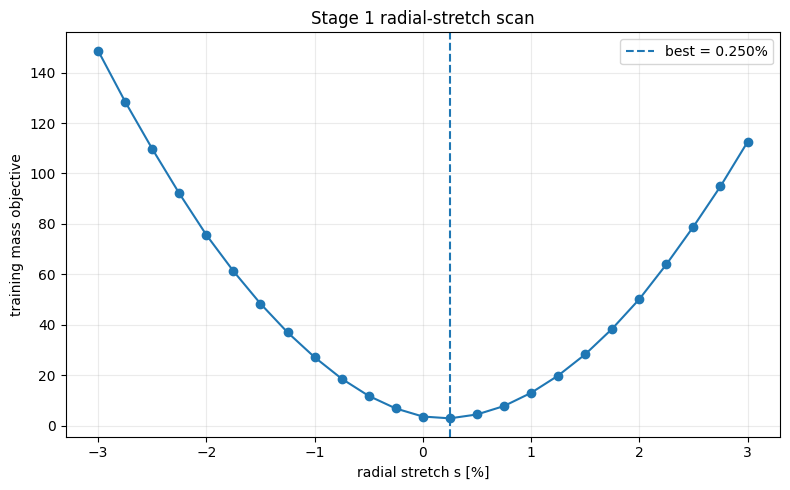

,stretch_fraction,objective,mean_abs_mass_error_mev,maximum_width_ratio
0,-0.0300,148.671389,12.152875,2.797227
1,-0.0275,128.445010,11.298467,2.700132
2,-0.0250,109.756093,10.446176,2.601921
3,-0.0225,92.092155,9.568896,2.495522
4,-0.0200,75.632074,8.669382,2.417752
5,-0.0175,61.289392,7.801797,2.319014
6,-0.0150,48.383859,6.926206,2.206377
7,-0.0125,37.007516,6.048216,2.071596
8,-0.0100,27.148914,5.161705,1.919553
9,-0.0075,18.639868,4.241168,1.765338


Stage 1 initial stretch: +0.2500%


In [16]:
# ============================================================
# Stage 1A: quick one-parameter scan
# ============================================================

scan_indices = select_indices(training_indices, stage1_scan_candidates, seed + 1100)

stage1_model = RadialStretchModel(0.0)
stage1_scan_table = None

if run_stage1_scan:
    rows = []
    for stretch in np.linspace(stage1_scan_min_fraction, stage1_scan_max_fraction, stage1_scan_points):
        stage1_model.set_stretch(stretch)
        prediction = evaluate_stage1(stage1_model, arrays, scan_indices)
        table = mass_table_from_prediction(prediction)
        rows.append({
            'stretch_fraction': float(stretch),
            'objective': stage1_scan_objective(table),
            'mean_abs_mass_error_mev': float(np.nanmean(np.abs(table['mean_error_after_mev']))),
            'maximum_width_ratio': float(np.nanmax(table['width_ratio'])),
        })
        print(f'scan s={100*stretch:+.3f}% objective={rows[-1]["objective"]:.4f}')

    stage1_scan_table = pd.DataFrame(rows)
    best_scan = stage1_scan_table.loc[stage1_scan_table['objective'].idxmin()]
    stage1_model.set_stretch(best_scan['stretch_fraction'])
    stage1_scan_table.to_csv(work_dir / 'stage1_radial_scan.csv', index=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(100.0 * stage1_scan_table['stretch_fraction'], stage1_scan_table['objective'], marker='o')
    ax.axvline(100.0 * best_scan['stretch_fraction'], linestyle='--', label=f'best = {100*best_scan["stretch_fraction"]:.3f}%')
    ax.set_xlabel('radial stretch s [%]')
    ax.set_ylabel('training mass objective')
    ax.set_title('Stage 1 radial-stretch scan')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(work_dir / 'stage1_radial_scan.pdf')
    plt.show()

    display(stage1_scan_table)
else:
    stage1_model.set_stretch(0.0)

print('Stage 1 initial stretch:', f'{100*stage1_model.value():+.4f}%')


epoch 00: s=+0.1458% loss=2.63357 mass=2.51691 residual=0.45905
epoch 01: s=+0.1644% loss=2.75311 mass=2.60993 residual=0.45932
epoch 02: s=+0.1741% loss=2.76703 mass=2.63412 residual=0.46016
epoch 03: s=+0.1678% loss=2.70881 mass=2.55947 residual=0.45908
epoch 04: s=+0.1902% loss=2.61744 mass=2.47748 residual=0.45910
epoch 05: s=+0.2033% loss=2.74255 mass=2.62492 residual=0.46063
epoch 06: s=+0.1950% loss=2.76125 mass=2.64405 residual=0.45983
epoch 07: s=+0.1818% loss=2.60824 mass=2.48736 residual=0.45973
epoch 08: s=+0.1716% loss=2.65263 mass=2.52099 residual=0.45892
epoch 09: s=+0.1732% loss=2.64949 mass=2.51819 residual=0.45970
epoch 10: s=+0.1786% loss=2.71663 mass=2.58877 residual=0.45992
epoch 11: s=+0.1755% loss=2.74528 mass=2.61881 residual=0.45912
epoch 12: s=+0.1714% loss=2.66353 mass=2.51888 residual=0.45916
epoch 13: s=+0.1792% loss=2.67538 mass=2.54375 residual=0.46004
epoch 14: s=+0.1800% loss=2.59802 mass=2.46981 residual=0.45876
epoch 15: s=+0.1835% loss=2.65671 mass=2

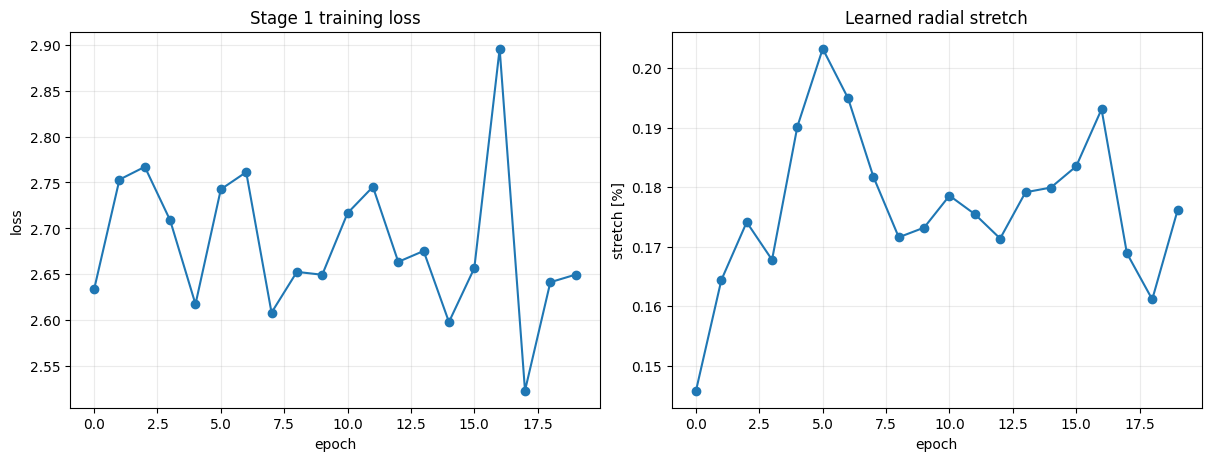

Final Stage 1 stretch: +0.16891%
Delta r at 39 cm: +0.0262 cm
Delta r at 70 cm: -0.0262 cm


In [17]:
# ============================================================
# Stage 1B: PyTorch refinement of the single stretch parameter
# ============================================================

history = []
best_loss = np.inf
best_stretch = stage1_model.value()
stale_epochs = 0

if run_stage1_fit:
    training_loader = DataLoader(
        CandidateDataset(arrays, training_indices),
        batch_size=min(stage1_candidate_batch_size, len(training_indices)),
        shuffle=True,
        num_workers=0,
    )
    optimizer = torch.optim.Adam(stage1_model.parameters(), lr=stage1_learning_rate)

    for epoch in range(stage1_epochs):
        stage1_model.train()
        sums = {'total': 0.0, 'pt_mass': 0.0, 'inclusive_mass': 0.0, 'width': 0.0, 'residual': 0.0}
        batches = 0

        for batch in training_loader:
            optimizer.zero_grad(set_to_none=True)
            total, terms = stage1_batch_loss(stage1_model, batch)
            total.backward()
            optimizer.step()
            with torch.no_grad():
                stage1_model.stretch_fraction.clamp_(-stage1_max_abs_stretch_fraction, stage1_max_abs_stretch_fraction)

            sums['total'] += float(total.detach())
            for key in ['pt_mass', 'inclusive_mass', 'width', 'residual']:
                sums[key] += float(terms[key].detach())
            batches += 1

        row = {'epoch': epoch, 'stretch_fraction': stage1_model.value()}
        row.update({key: value / max(batches, 1) for key, value in sums.items()})
        history.append(row)
        print(f'epoch {epoch:02d}: s={100*row["stretch_fraction"]:+.4f}% loss={row["total"]:.5f} mass={row["pt_mass"]:.5f} residual={row["residual"]:.5f}')

        if row['total'] < best_loss - stage1_minimum_improvement:
            best_loss = row['total']
            best_stretch = row['stretch_fraction']
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= stage1_patience:
                print('Early stop: no useful Stage-1 improvement.')
                break

    stage1_model.set_stretch(best_stretch)

stage1_history = pd.DataFrame(history)
if not stage1_history.empty:
    stage1_history.to_csv(work_dir / 'stage1_training_history.csv', index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    axes[0].plot(stage1_history['epoch'], stage1_history['total'], marker='o')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('loss')
    axes[0].set_title('Stage 1 training loss')
    axes[0].grid(alpha=0.25)
    axes[1].plot(stage1_history['epoch'], 100.0 * stage1_history['stretch_fraction'], marker='o')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('stretch [%]')
    axes[1].set_title('Learned radial stretch')
    axes[1].grid(alpha=0.25)
    plt.show()

torch.save({'state_dict': stage1_model.state_dict(), 'stretch_fraction': stage1_model.value(), 'pivot_r_cm': stage1_pivot_r_cm}, checkpoint_dir / 'stage1_radial_stretch.pt')
print('Final Stage 1 stretch:', f'{100*stage1_model.value():+.5f}%')
print('Delta r at 39 cm:', f'{-stage1_model.value()*(39.0-stage1_pivot_r_cm):+.4f} cm')
print('Delta r at 70 cm:', f'{-stage1_model.value()*(70.0-stage1_pivot_r_cm):+.4f} cm')


,pt_low,pt_high,entries,neff,mean_before,mean_after,mean_error_before_mev,mean_error_after_mev,width_before_mev,width_after_mev,width_ratio
0,0.5,0.8,730,572.123074,0.493829,0.494474,-3.782124,-3.137107,4.821149,5.512599,1.143420
1,0.8,1.1,962,768.577930,0.495410,0.495819,-2.200844,-1.791893,5.167226,6.215694,1.202907
2,1.1,1.4,1213,950.999091,0.496395,0.497093,-1.216287,-0.517893,5.584861,6.699816,1.199639
3,1.4,1.8,1965,1467.188385,0.496093,0.496715,-1.517760,-0.895672,6.871663,8.046723,1.171001
4,1.8,2.2,1598,1207.540905,0.497322,0.498113,-0.289361,0.501682,8.554109,9.727999,1.137231
5,2.2,3.0,1221,879.409320,0.498014,0.498635,0.402631,1.024127,9.376727,10.632117,1.133884


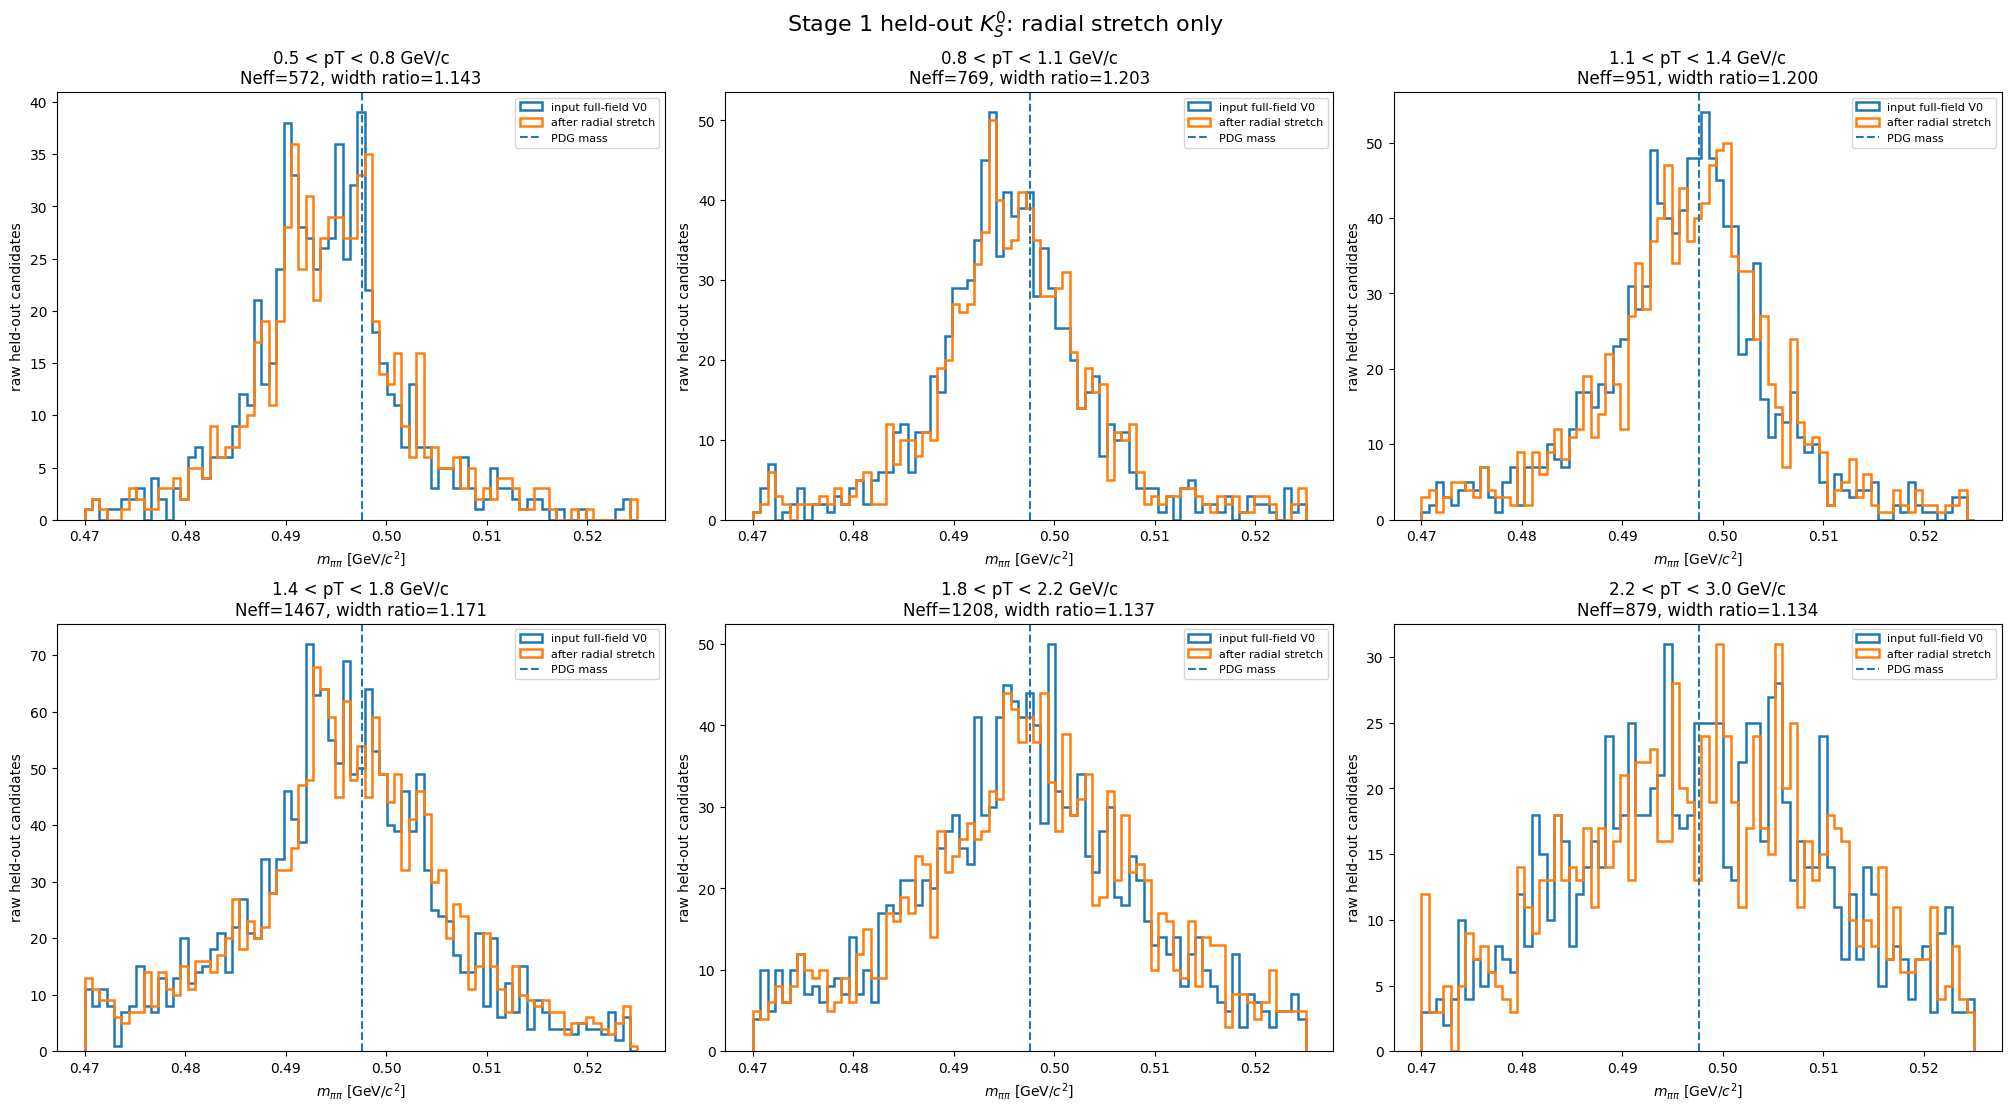

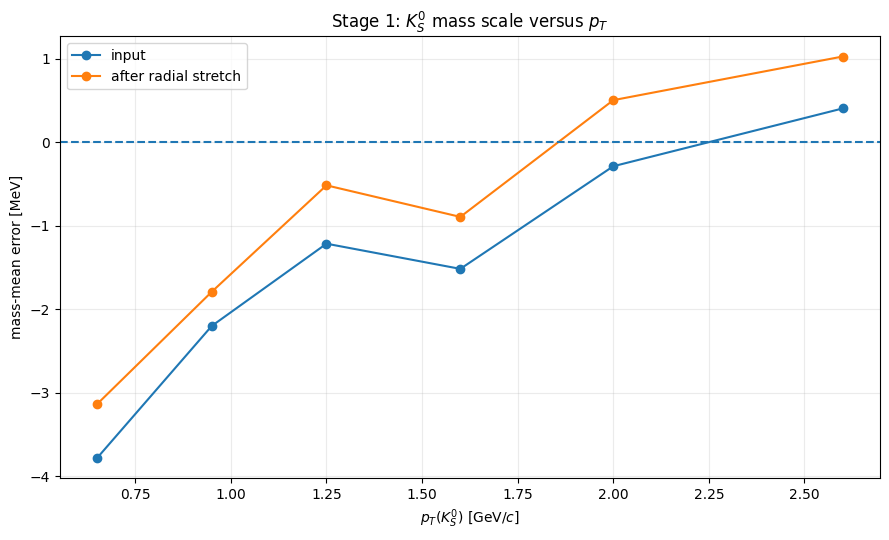

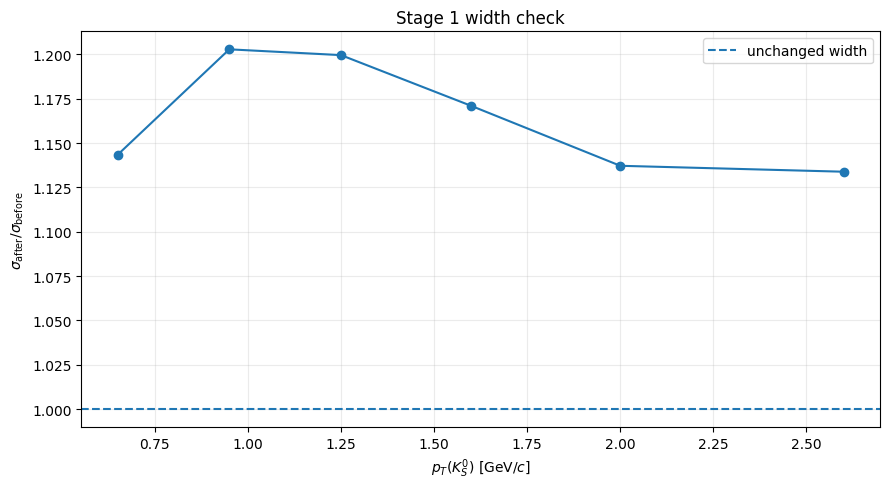

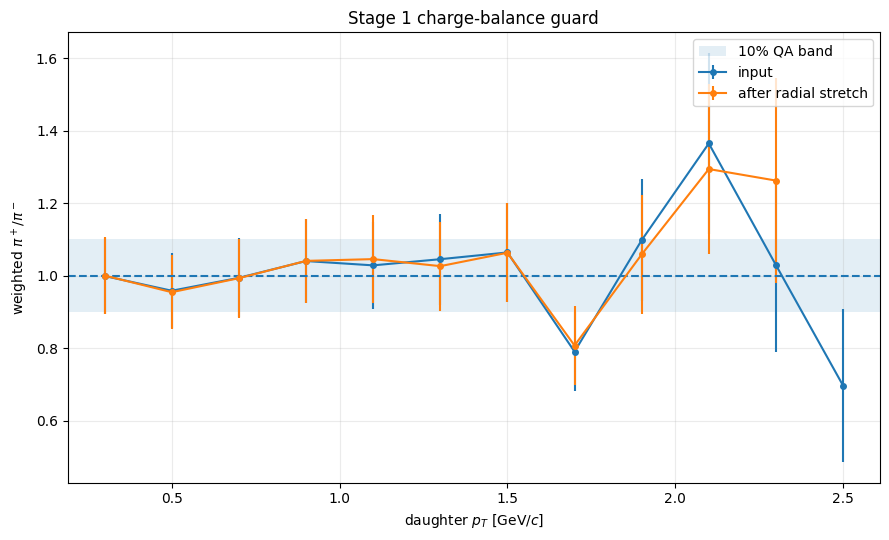

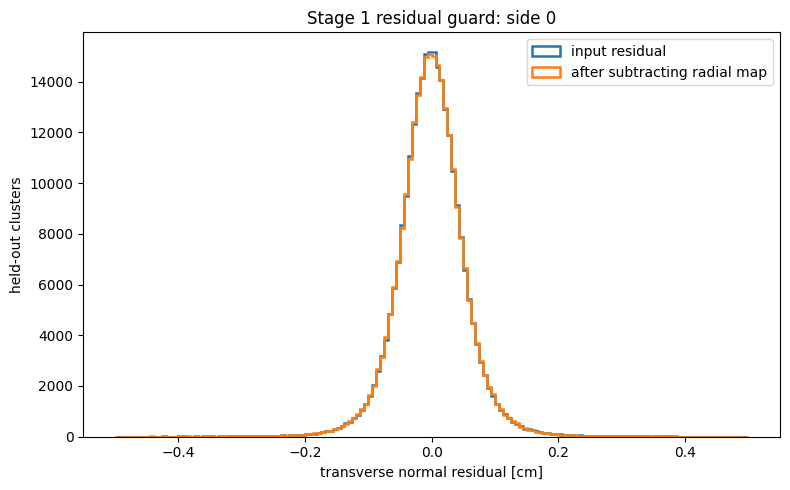

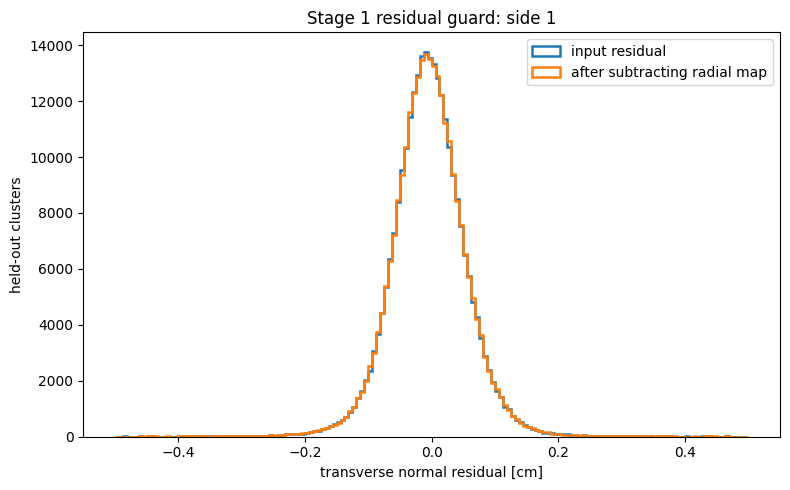

,side,clusters,rmse_before_cm,rmse_after_cm,rmse_ratio
0,0,272027,0.065616,0.065707,1.001393
1,1,278542,0.071323,0.071384,1.000856


In [18]:
# ============================================================
# Held-out Stage 1 QA: mass, width, charge balance, residuals
# ============================================================

validation_indices_qa = select_indices(validation_indices, maximum_validation_candidates, seed + 2200)
stage1_validation = evaluate_stage1(stage1_model, arrays, validation_indices_qa)
stage1_mass_table = mass_table_from_prediction(stage1_validation)
stage1_mass_table.to_csv(work_dir / 'stage1_kshort_mass_vs_pt.csv', index=False)
display(stage1_mass_table)

# K0S raw shapes.
figure, axes = plt.subplots(2, 3, figsize=(20, 11), constrained_layout=True)
axes = axes.ravel()
for axis, row in zip(axes, stage1_mass_table.itertuples(index=False)):
    selected = (stage1_validation['pair_pt'] >= row.pt_low) & (stage1_validation['pair_pt'] < row.pt_high)
    axis.hist(stage1_validation['mass_before'][selected], bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.8, label='input full-field V0')
    axis.hist(stage1_validation['mass_after'][selected], bins=75, range=(0.47, 0.525), histtype='step', linewidth=1.8, label='after radial stretch')
    axis.axvline(pdg_kshort_mass, linestyle='--', linewidth=1.5, label='PDG mass')
    axis.set_title(f'{row.pt_low:.1f} < pT < {row.pt_high:.1f} GeV/c\nNeff={row.neff:.0f}, width ratio={row.width_ratio:.3f}')
    axis.set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axis.set_ylabel('raw held-out candidates')
    axis.legend(fontsize=8)
figure.suptitle(r'Stage 1 held-out $K^0_S$: radial stretch only', fontsize=16)
plt.savefig(work_dir / 'stage1_kshort_mass_shapes.pdf')
plt.show()

pt_center = 0.5 * (stage1_mass_table['pt_low'].to_numpy() + stage1_mass_table['pt_high'].to_numpy())

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(pt_center, stage1_mass_table['mean_error_before_mev'], marker='o', label='input')
ax.plot(pt_center, stage1_mass_table['mean_error_after_mev'], marker='o', label='after radial stretch')
ax.axhline(0.0, linestyle='--')
ax.set_xlabel(r'$p_T(K^0_S)$ [GeV/$c$]')
ax.set_ylabel('mass-mean error [MeV]')
ax.set_title(r'Stage 1: $K^0_S$ mass scale versus $p_T$')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'stage1_mass_scale_vs_pt.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pt_center, stage1_mass_table['width_ratio'], marker='o')
ax.axhline(1.0, linestyle='--', label='unchanged width')
ax.set_xlabel(r'$p_T(K^0_S)$ [GeV/$c$]')
ax.set_ylabel(r'$\sigma_{\rm after}/\sigma_{\rm before}$')
ax.set_title('Stage 1 width check')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'stage1_width_ratio_vs_pt.pdf')
plt.show()

# Charge balance is QA only in Stage 1.
charge_weight = stage1_validation['pair_weight'] * stage1_validation['signal_probability']
charge_before = charge_balance_table(stage1_validation['pt_positive_before'], stage1_validation['pt_negative_before'], charge_weight)
charge_after = charge_balance_table(stage1_validation['pt_positive_after'], stage1_validation['pt_negative_after'], charge_weight)
charge_before['state'] = 'before'
charge_after['state'] = 'after'
pd.concat([charge_before, charge_after], ignore_index=True).to_csv(work_dir / 'stage1_charge_balance.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
for table, label in [(charge_before, 'input'), (charge_after, 'after radial stretch')]:
    selected = table['active'].to_numpy(bool)
    ax.errorbar(table.loc[selected, 'pt'], table.loc[selected, 'ratio'], yerr=table.loc[selected, 'sigma_ratio'], fmt='o-', ms=4, label=label)
ax.axhline(1.0, linestyle='--')
ax.axhspan(0.90, 1.10, alpha=0.12, label='10% QA band')
ax.set_xlabel(r'daughter $p_T$ [GeV/$c$]')
ax.set_ylabel(r'weighted $\pi^+/\pi^-$')
ax.set_title('Stage 1 charge-balance guard')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(work_dir / 'stage1_charge_balance.pdf')
plt.show()

# Residual guard: compare measured normal residual before and after subtracting the radial map.
residual_rows = []
for side in [0, 1]:
    flat = flatten_training_clusters_for_side(arrays, validation_indices_qa, side)
    predicted_parts = []
    chunk_size = 200_000
    with torch.no_grad():
        for start in range(0, len(flat['r']), chunk_size):
            stop = min(start + chunk_size, len(flat['r']))
            delta_r, _, _ = stage1_model(
                torch.from_numpy(flat['r'][start:stop]),
                torch.from_numpy(flat['phi'][start:stop]),
                torch.from_numpy(flat['z'][start:stop]),
            )
            predicted_parts.append(delta_r.numpy() * flat['normal_projection_r'][start:stop])

    predicted = np.concatenate(predicted_parts)
    before = flat['res_normal']
    after = before - predicted
    before_rmse = float(np.sqrt(np.mean(before ** 2)))
    after_rmse = float(np.sqrt(np.mean(after ** 2)))
    residual_rows.append({'side': side, 'clusters': len(before), 'rmse_before_cm': before_rmse, 'rmse_after_cm': after_rmse, 'rmse_ratio': after_rmse / max(before_rmse, 1.0e-12)})

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(before, bins=160, range=(-0.5, 0.5), histtype='step', linewidth=1.8, label='input residual')
    ax.hist(after, bins=160, range=(-0.5, 0.5), histtype='step', linewidth=1.8, label='after subtracting radial map')
    ax.set_xlabel('transverse normal residual [cm]')
    ax.set_ylabel('held-out clusters')
    ax.set_title(f'Stage 1 residual guard: side {side}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(work_dir / f'stage1_residual_side{side}.pdf')
    plt.show()

stage1_residual_table = pd.DataFrame(residual_rows)
stage1_residual_table.to_csv(work_dir / 'stage1_residual_guard.csv', index=False)
display(stage1_residual_table)


In [19]:
# ============================================================
# Optional Lambda / anti-Lambda held-out validation
# ============================================================

if run_lambda_validation:
    lambda_rows = []
    for channel, label in [(1, 'Lambda'), (2, 'AntiLambda')]:
        if channel not in validation_npz_files:
            continue
        lambda_arrays = load_npz_dictionary(validation_npz_files[channel])
        indices = np.flatnonzero(lambda_arrays['event_parity'].astype(np.int64) == validation_parity)
        indices = select_indices(indices, maximum_validation_candidates, seed + 3000 + channel)
        prediction = evaluate_stage1(stage1_model, lambda_arrays, indices, channel=channel)
        before = peak_metrics(prediction['mass_before'])
        after = peak_metrics(prediction['mass_after'])
        lambda_rows.append({
            'channel': label,
            'entries': len(indices),
            'mean_before': before['mean'],
            'mean_after': after['mean'],
            'width_before': before['width'],
            'width_after': after['width'],
        })

        plt.figure(figsize=(8, 5))
        plt.hist(prediction['mass_before'], bins=100, range=(1.095, 1.140), histtype='step', linewidth=1.8, label='input')
        plt.hist(prediction['mass_after'], bins=100, range=(1.095, 1.140), histtype='step', linewidth=1.8, label='after radial stretch')
        plt.axvline(1.115683, linestyle='--', label='PDG Lambda')
        plt.xlabel(r'$m_{p\pi}$ [GeV/$c^2$]')
        plt.ylabel('held-out candidates')
        plt.title(label)
        plt.legend()
        plt.tight_layout()
        plt.show()

    lambda_summary = pd.DataFrame(lambda_rows)
    lambda_summary.to_csv(work_dir / 'stage1_lambda_validation.csv', index=False)
    display(lambda_summary)
else:
    print('Lambda validation disabled for the first Stage-1 run.')


Lambda validation disabled for the first Stage-1 run.


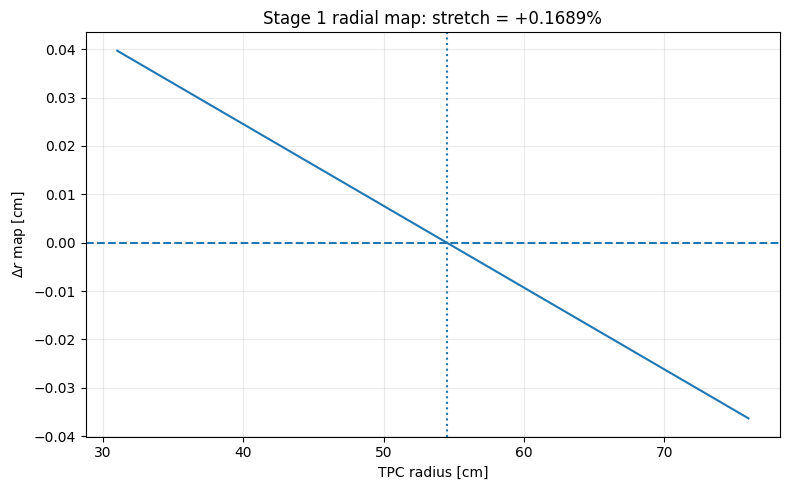

{
  "model": "global linear radial stretch",
  "map_convention": "corrected_r = measured_r - delta_r",
  "pivot_r_cm": 54.5,
  "stretch_fraction": 0.0016890594270080328,
  "stretch_percent": 0.16890594270080328,
  "delta_r_at_39_cm": 0.02618042111862451,
  "delta_r_at_70_cm": -0.02618042111862451,
  "direction_correction_strength": 0.0,
  "field_evaluation_mode": "linearized",
  "training_profile": "short",
  "mean_abs_mass_error_before_mev": 1.5681677193260708,
  "mean_abs_mass_error_after_mev": 1.3113959009832439,
  "maximum_width_ratio": 1.2029072859378536,
  "charge_mean_abs_ratio_error_before": 0.10261678695678711,
  "charge_mean_abs_ratio_error_after": 0.09414833039045334,
  "residual_rmse_ratio_side0": 1.0013928979351114,
  "residual_rmse_ratio_side1": 1.0008555482513022
}
Stage 1 complete. Stage 2 and Stage 3 intentionally remain off.


In [20]:
# ============================================================
# Save the Stage 1 radial calibration
# ============================================================

stretch = stage1_model.value()
radius = np.linspace(31.0, 76.0, 181)
delta_r = -stretch * (radius - stage1_pivot_r_cm)
radial_map = pd.DataFrame({'r_cm': radius, 'delta_r_cm': delta_r})
radial_map.to_csv(work_dir / 'stage1_radial_map.csv', index=False)

mass_usable = stage1_mass_table['neff'] >= pt_mass_scale_minimum_effective_entries
charge_before_active = charge_before['active'].to_numpy(bool)
charge_after_active = charge_after['active'].to_numpy(bool)

stage1_summary = {
    'model': 'global linear radial stretch',
    'map_convention': 'corrected_r = measured_r - delta_r',
    'pivot_r_cm': stage1_pivot_r_cm,
    'stretch_fraction': stretch,
    'stretch_percent': 100.0 * stretch,
    'delta_r_at_39_cm': float(-stretch * (39.0 - stage1_pivot_r_cm)),
    'delta_r_at_70_cm': float(-stretch * (70.0 - stage1_pivot_r_cm)),
    'direction_correction_strength': direction_correction_strength,
    'field_evaluation_mode': field_evaluation_mode,
    'training_profile': training_profile,
    'mean_abs_mass_error_before_mev': float(np.nanmean(np.abs(stage1_mass_table.loc[mass_usable, 'mean_error_before_mev']))),
    'mean_abs_mass_error_after_mev': float(np.nanmean(np.abs(stage1_mass_table.loc[mass_usable, 'mean_error_after_mev']))),
    'maximum_width_ratio': float(np.nanmax(stage1_mass_table.loc[mass_usable, 'width_ratio'])),
    'charge_mean_abs_ratio_error_before': float(np.nanmean(np.abs(charge_before.loc[charge_before_active, 'ratio'] - 1.0))),
    'charge_mean_abs_ratio_error_after': float(np.nanmean(np.abs(charge_after.loc[charge_after_active, 'ratio'] - 1.0))),
    'residual_rmse_ratio_side0': float(stage1_residual_table.loc[stage1_residual_table['side'] == 0, 'rmse_ratio'].iloc[0]),
    'residual_rmse_ratio_side1': float(stage1_residual_table.loc[stage1_residual_table['side'] == 1, 'rmse_ratio'].iloc[0]),
}
with open(work_dir / 'stage1_radial_summary.json', 'w') as output:
    json.dump(stage1_summary, output, indent=2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(radius, delta_r)
ax.axhline(0.0, linestyle='--')
ax.axvline(stage1_pivot_r_cm, linestyle=':')
ax.set_xlabel('TPC radius [cm]')
ax.set_ylabel(r'$\Delta r$ map [cm]')
ax.set_title(f'Stage 1 radial map: stretch = {100*stretch:+.4f}%')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(work_dir / 'stage1_radial_map.pdf')
plt.show()

print(json.dumps(stage1_summary, indent=2))

if run_stage2 or run_stage3:
    raise RuntimeError('Stop after Stage 1. Review mass-vs-pT, width, residual, and charge-balance QA before enabling later stages.')
else:
    print('Stage 1 complete. Stage 2 and Stage 3 intentionally remain off.')


## Stop here

Review these Stage-1 outputs before adding \(r\Delta\phi\):

- mass mean versus mother \(p_T\) should become flatter and approach the PDG mass;
- raw K0S widths should not broaden materially;
- transverse-normal residual RMS should not degrade substantially;
- global \(\pi^+/\pi^-\) should remain compatible with the 10% QA band.

Only after this looks physically sensible should Stage 2 be implemented/enabled.
